## Introduction

<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Machine Learning Project
MoraGarcia Carmen, De Artiagoitia Léo, Dubouchet Chloé et Perrin Alicia


The data is taken from the KAGGLE competition website; it is the data set "Cardivascular Disease Risk
Prediction Dataset" available here: https://www.kaggle.com/datasets/bertnardomariouskono/cardiovasculardisease-risk-prediction-dataset.


This dataset contains 15,000 synthetic patient medical records specifically designed to predict the risk of
cardiovascular disease. Although synthetic, the data is generated using medical heuristics to ensure realistic
correlations between variables, such as the relationship between age, BMI, and blood pressure. The dataset
includes 19 variables for 15,000 patients.

**WARNING** In order to have exactly the same training and test samples in both languages ​​so that their results can be compared afterwards, it is imperative to run the python notebook before this one.

In [ ]:
options(warn = -1)

# Manipulation de données
library(tidyverse)
library(reshape2)
library(fastDummies)


# Visualisation
library(ggplot2)
library(GGally)
library(ggfortify)
library(gridExtra)
library(plotly)
library(corrplot)


# Analyse multivariée
library(FactoMineR)
library(factoextra)


# Modélisation statistique
library(MASS)
library(glmnet)
library(nnet)
library(rpart)
library(rpart.plot)


# Machine Learning
library(randomForest)
library(gbm)
library(e1071)
library(caret)


# Évaluation des modèles
library(pROC)
library(ROCR)
library(Metrics)
library(MLmetrics)
library(formattable)


# Calcul parallèle
library(doParallel)

## 1. Exploratory data analysis

### a. Read the table of data

In [3]:
df<-read.csv("archive/healthcare_synthetic_data.csv", sep=",")
head(df)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


We start by checking the nature of the different variables and their encoding.

In [4]:
df$Gender <- factor(df$Gender, labels = c("Woman", "Man"))

df$Smoking_Status <- factor(df$Smoking_Status, labels = c("Non_Smoker", "Smoker"))

df$Alcohol_Consumption <- factor(df$Alcohol_Consumption, labels = c("Non", "Moderate", "Heavy"))

df$Physical_Activity_Level <- factor(df$Physical_Activity_Level)

df$Family_History <- factor(df$Family_History, labels = c("No", "Yes"))

df$Heart_Disease_Risk <- factor(df$Heart_Disease_Risk, labels = c("Low", "High"))

Secondly, we transform some variable to be Gaussian.

In [5]:
df <- df %>%
  mutate(
    R_Weight_kg = sqrt(Weight_kg),
    R_BMI = sqrt(BMI)
  )

variables <- c('Age', 'Height_cm', 'R_Weight_kg', 'R_BMI', 'Systolic_BP', 
               'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 
               'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 
               'Sleep_Hours')

df <- df %>% 
  select(-BMI, -Weight_kg)

summary(df)

  Patient_ID             Age          Gender       Height_cm    
 Length:15000       Min.   :25.00   Woman:7622   Min.   :138.5  
 Class :character   1st Qu.:46.00   Man  :7378   1st Qu.:158.5  
 Mode  :character   Median :55.00                Median :164.7  
                    Mean   :54.54                Mean   :165.3  
                    3rd Qu.:63.00                3rd Qu.:172.0  
                    Max.   :85.00                Max.   :198.1  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  
 Cholesterol_HDL Fasting_Blood_Sugar    Smoking_Status  Alcohol_Consu

## 2. Prediction of Heart’s Disease Risk
We consider the problem of predicting the variable Heart_Disease_Risk from the other variables from a machine learning point of view, i.e. focusing on model performance. The aim is to determine the best performance we can expect, and which models achieve it. Because we already did this work in Python, the aim of this work is to compare if we obtain better results with the R language. 

### a. Importation of training sample and a test sample

We decided to export the indices of the individuals in each sample so that we could compare the results obtained in R and in Python on the same data.

In [6]:
train_idx <- read.csv("train_indices.csv")$index
test_idx <- read.csv("test_indices.csv")$index

train_idx_r <- train_idx + 1
test_idx_r <- test_idx + 1

df_train <- df[train_idx_r, ]
df_test <- df[test_idx_r, ]

set.seed(42)

In [70]:
X_train <- df_train[, !(names(df_train) %in% c("Patient_ID", "Heart_Disease_Risk"))]
Y_train <- as.numeric(df_train$Heart_Disease_Risk) - 1  
X_test  <- df_test[, !(names(df_test) %in% c("Patient_ID", "Heart_Disease_Risk"))]
Y_test  <- as.numeric(df_test$Heart_Disease_Risk) - 1   

quanti <- c("Age", "Height_cm", "R_Weight_kg", "R_BMI", "Systolic_BP", "Diastolic_BP",
            "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
            "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

X_train_scaled <- scale(X_train[, quanti])
X_train[, quanti] <- X_train_scaled
X_test[, quanti]  <- scale(X_test[, quanti],
                            center = attr(X_train_scaled, "scaled:center"),
                            scale  = attr(X_train_scaled, "scaled:scale"))

X_train <- dummy_cols(X_train, remove_first_dummy = TRUE, remove_selected_columns = TRUE)
X_test  <- dummy_cols(X_test,  remove_first_dummy = TRUE, remove_selected_columns = TRUE)

X_train <- as.data.frame(lapply(X_train, as.numeric))
X_test  <- as.data.frame(lapply(X_test,  as.numeric))


X_test <- X_test[, colnames(X_train)]

### b. Comparaison of forecasting models

#### i) Linear model

##### 1-With variable selection: Ridge

In [71]:

# We use glm for the binomial family
logit_simple <- glm(Heart_Disease_Risk ~ ., data = cbind(X_train, Heart_Disease_Risk = Y_train), family = binomial)

# test error
probs_simple <- predict(logit_simple, newdata = X_test, type = "response")
preds_simple <- ifelse(probs_simple > 0.5, 1, 0)
err_simple <- mean(preds_simple != Y_test)

cat(sprintf("Model error without selection : %.4f\n", err_simple))

Model error without selection : 0.2640


In [72]:
summary(probs_simple)  # all proba > 0.5 and < 0.5 
table(preds_simple, Y_test)  

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.01118 0.21068 0.39872 0.44130 0.66441 0.99231 

            Y_test
preds_simple    0    1
           0 1339  469
           1  323  869

##### 2- With variable regression : Lasso

In [73]:
set.seed(42)
x_train_mat <- as.matrix(X_train)
y_train_vec <- as.numeric(Y_train)


cv_lasso <- cv.glmnet(x_train_mat, y_train_vec, family = "binomial", alpha = 1, nfolds = 5, type.measure = "class")# in glmnet, alpha = 1 is equivalent to the lasso + automatic cross validation

best_lambda <- cv_lasso$lambda.min
cat("Best lambda =", best_lambda, "\n")

# Note : the error of CV is stocked in cv_lasso$cvm !!
cat(sprintf("Best score (error CV) = %f\n", min(cv_lasso$cvm)))

Best lambda = 0.002680766 
Best score (error CV) = 0.260583


In [74]:
# Prediction with the best lambda found
probs_opt <- predict(cv_lasso, newx = as.matrix(X_test), s = "lambda.min", type = "response")
preds_opt <- ifelse(probs_opt > 0.5, 1, 0)

# test error
err_test_lasso <- mean(preds_opt != Y_test)
cat(sprintf("Error on the test sample : %.4f\n", err_test_lasso))

Error on the test sample : 0.2613


Those 2 linear models present equivalent (but better) results than the ones obtained in Python. 

In [75]:
# finding the coeffs for the best lambdas
coeffs_lasso <- coef(cv_lasso, s = "lambda.min")
df_coeffs <- data.frame(
  Variable = rownames(coeffs_lasso),
  Coeff = as.vector(coeffs_lasso)
)

# Note: we delet the intercept to find the combinations
df_coeffs_vars <- df_coeffs[df_coeffs$Variable != "(Intercept)", ]
variables_supprimees <- df_coeffs_vars[df_coeffs_vars$Coeff == 0, "Variable"]

cat(sprintf("Number of deleted variables by Lasso : %d\n", length(variables_supprimees)))
cat("Deleted variables :", paste(variables_supprimees, collapse = ", "), "\n")

Number of deleted variables by Lasso : 5
Deleted variables : Height_cm, Diastolic_BP, Cholesterol_Total, Gender_Man, Alcohol_Consumption_Heavy 


Lasso keeps 15 variables and deletes 5 of them


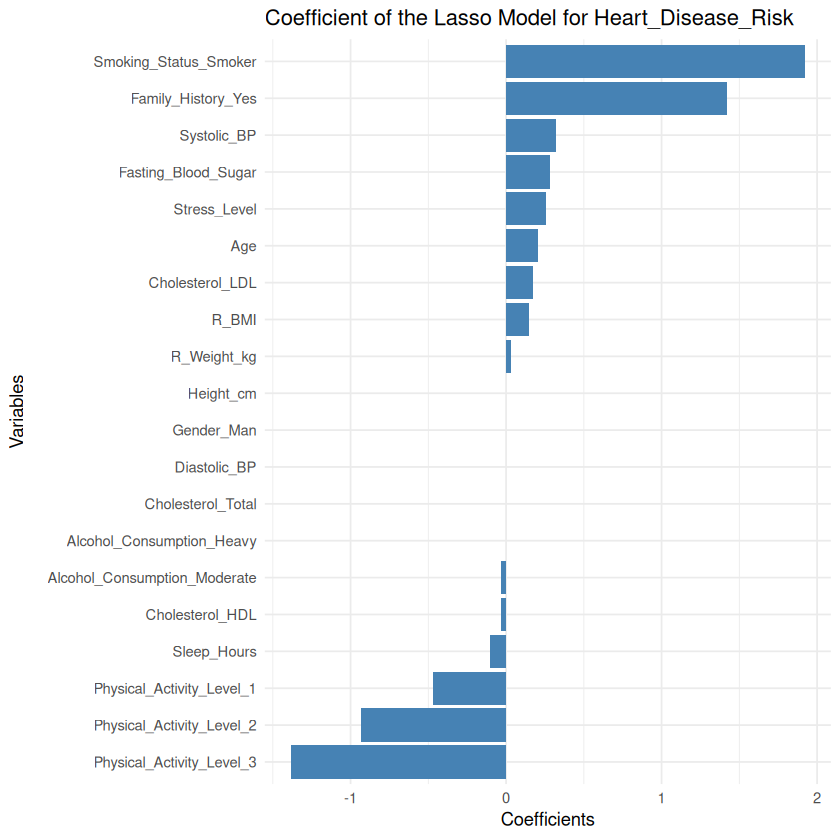

In [76]:
df_coeffs_vars <- df_coeffs_vars[order(df_coeffs_vars$Coeff), ]

cat("Lasso keeps", sum(df_coeffs_vars$Coeff != 0), "variables and deletes", sum(df_coeffs_vars$Coeff == 0), "of them\n")

# graph
ggplot(df_coeffs_vars, aes(x = reorder(Variable, Coeff), y = Coeff)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Coefficient of the Lasso Model for Heart_Disease_Risk",
    x = "Variables",
    y = "Coefficients"
  ) +
  theme_minimal()

The Lasso is more efficient in R, deleting 5 variables, against 1 in the Python. 

In [77]:
# Class prediction (Threshold= 0.5 par défaut)
y_chap <- ifelse(probs_opt > 0.5, 1, 0)

# matrix confusion
table_confusion <- table(Predicton = y_chap, Reel = Y_test)
print(table_confusion)

         Reel
Predicton    0    1
        0 1349  471
        1  313  867


In [78]:
conf_matrix <- confusionMatrix(as.factor(y_chap), as.factor(Y_test), positive = "1")
print(conf_matrix)

# equivalent to AUC
roc_lasso <- roc(Y_test, as.vector(probs_opt))
cat(sprintf("AUC of the Lasso Model : %.4f\n", auc(roc_lasso)))

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1349  471
         1  313  867
                                          
               Accuracy : 0.7387          
                 95% CI : (0.7226, 0.7543)
    No Information Rate : 0.554           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.465           
                                          
 Mcnemar's Test P-Value : 2.057e-08       
                                          
            Sensitivity : 0.6480          
            Specificity : 0.8117          
         Pos Pred Value : 0.7347          
         Neg Pred Value : 0.7412          
             Prevalence : 0.4460          
         Detection Rate : 0.2890          
   Detection Prevalence : 0.3933          
      Balanced Accuracy : 0.7298          
                                          
       'Positive' Class : 1               
                        

Setting levels: control = 0, case = 1



Setting direction: controls < cases



AUC of the Lasso Model : 0.8061


This high deletion of features has no impact on the AUC which is slightly better than the one obteined in Python. 

##### 3- Logistic Function

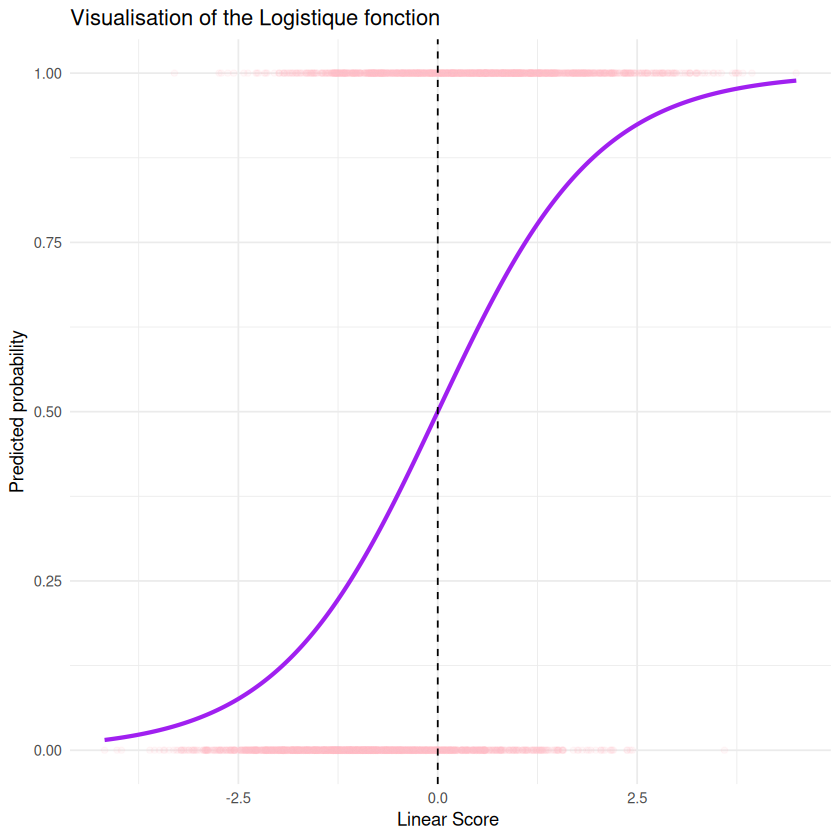

In [79]:
# Calcul of the linear score 
z <- predict(cv_lasso, newx = as.matrix(X_test), s = "lambda.min", type = "link")

# sigmoide curve
z_range <- seq(min(z), max(z), length.out = 1000)
p_range <- 1 / (1 + exp(-z_range))

# Graph using ggplot2
df_viz <- data.frame(z = as.vector(z), real = as.factor(Y_test))
df_curve <- data.frame(z_range = z_range, p_range = p_range)

ggplot() +
  geom_point(data = df_viz, aes(x = z, y = as.numeric(as.character(real))), 
             alpha = 0.1, color = "pink") +
  geom_line(data = df_curve, aes(x = z_range, y = p_range), color = "purple", size = 1.2) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(title = "Visualisation of the Logistique fonction ",
       x = "Linear Score ", y = "Predicted probability") +
  theme_minimal()

The logistic function is the same than the one obtained in Python but illustrates well the good AUC score obtained.

#### ii)  SVM

In [81]:
set.seed(42)
svm_lin_tune <- tune(svm, 
                     train.x = as.matrix(X_train),
                     train.y = as.factor(Y_train),
                     kernel  = "linear",
                     ranges  = list(cost = c(0.1, 0.4, 0.5, 0.6, 0.8, 1, 1.4, 2)))

cat("Best C :", svm_lin_tune$best.parameters$cost, "\n")
cat(sprintf("Error CV  : %.4f\n", svm_lin_tune$best.performance))

# Réentraîne avec probability = TRUE pour pouvoir calculer l'AUC
svm_lin_best <- svm(x           = as.matrix(X_train),
                    y           = as.factor(Y_train),
                    kernel      = "linear",
                    cost        = svm_lin_tune$best.parameters$cost,
                    probability = TRUE)

pred_svm_lin <- predict(svm_lin_best, newdata = as.matrix(X_test))
err_test_svm <- mean(pred_svm_lin != Y_test)
cat(sprintf("Error test : %.4f\n", err_test_svm))

# Probabilités pour la courbe ROC
prob_svm_lin <- attr(predict(svm_lin_best, newdata = as.matrix(X_test),
                             probability = TRUE),
                     "probabilities")[, "1"]

Best C : 2 
Error CV  : 0.2700
Error test : 0.2713


In [86]:
param_grid <- expand.grid(
  C     = c(0.5, 1, 2, 5, 10),
  gamma = c(0.01, 0.001)
)

results_file <- file.path(getwd(), "gridsearch_progress.csv")
cat("Beginning :", nrow(param_grid), "combinaisons to test\n")

X_train_mat <- as.matrix(X_train)
Y_train_fac  <- as.factor(Y_train)

for(i in 1:nrow(param_grid)) {
  p <- param_grid[i, ]
  cat(sprintf("Test %d/%d : C=%s, gamma=%s... ", i, nrow(param_grid), p$C, p$gamma))

model_tune <- tune(
    svm,
    train.x = X_train_mat,   
    train.y = Y_train_fac,     
    kernel  = "radial",
    ranges  = list(cost = p$C, gamma = p$gamma),
    tunecontrol = tune.control(cross = 10)
)
  current_accuracy <- 1 - model_tune$best.performance

  res <- data.frame(
    params   = paste0("C=", p$C, ", gamma=", p$gamma),
    accuracy = current_accuracy,
    error    = 1 - current_accuracy
  )

  file_exists_before <- file.exists(results_file)
  write.table(res, file      = results_file,
                   append    = file_exists_before,
                   sep       = ",",
                   row.names = FALSE,
                   col.names = !file_exists_before)

  cat(sprintf("OK (Score: %.4f)\n", current_accuracy))
}

cat("\nDone!!\n")

Beginning : 10 combinaisons to test


Test 1/10 : C=0.5, gamma=0.01... OK (Score: 0.7182)
Test 2/10 : C=1, gamma=0.01... OK (Score: 0.7215)
Test 3/10 : C=2, gamma=0.01... OK (Score: 0.7241)
Test 4/10 : C=5, gamma=0.01... OK (Score: 0.7272)
Test 5/10 : C=10, gamma=0.01... OK (Score: 0.7282)
Test 6/10 : C=0.5, gamma=0.001... OK (Score: 0.7242)
Test 7/10 : C=1, gamma=0.001... OK (Score: 0.7236)
Test 8/10 : C=2, gamma=0.001... OK (Score: 0.7225)
Test 9/10 : C=5, gamma=0.001... OK (Score: 0.7256)
Test 10/10 : C=10, gamma=0.001... OK (Score: 0.7256)

Done!!


In [87]:

df_results <- read.csv("gridsearch_progress.csv")


best_row <- df_results[which.max(df_results$accuracy), ]
cat("Meilleurs paramètres trouvés :", best_row$params, "\n")

best_c <- as.numeric(gsub(".*C=([0-9.]+).*", "\\1", best_row$params))
best_gamma <- as.numeric(gsub(".*gamma=([0-9.]+).*", "\\1", best_row$params))

# Note: probability = TRUE necessary to have the score later
best_svm <- svm(x = as.matrix(X_train), 
                y = as.factor(Y_train), 
                kernel = "radial", 
                cost = best_c, 
                gamma = best_gamma, 
                probability = TRUE)

Meilleurs paramètres trouvés : C=10, gamma=0.01 


In [88]:

y_pred <- predict(best_svm, newdata = as.matrix(X_test))


table_final <- table(Prédit = y_pred, Réel = Y_test)
print(table_final)

levels(y_pred) <- c("Low Risk (0)", "High Risk (1)")
Y_test_factor <- as.factor(Y_test)
levels(Y_test_factor) <- c("Low Risk (0)", "High Risk (1)")

final_report <- confusionMatrix(y_pred, Y_test_factor)
print(final_report)

cat("\n--- Metric details ---\n")
print(final_report$byClass[c("Precision", "Recall", "F1")])

      Réel
Prédit    0    1
     0 1361  505
     1  301  833
Confusion Matrix and Statistics

               Reference
Prediction      Low Risk (0) High Risk (1)
  Low Risk (0)          1361           505
  High Risk (1)          301           833
                                          
               Accuracy : 0.7313          
                 95% CI : (0.7151, 0.7471)
    No Information Rate : 0.554           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4481          
                                          
 Mcnemar's Test P-Value : 8.654e-13       
                                          
            Sensitivity : 0.8189          
            Specificity : 0.6226          
         Pos Pred Value : 0.7294          
         Neg Pred Value : 0.7346          
             Prevalence : 0.5540          
         Detection Rate : 0.4537          
   Detection Prevalence : 0.6220          
      Balanced Accur

The results are similar than the Python's. However there are tiny changes for the SVM to identify the True positive, the R struggle a bit more to capture 17 True positives. 

#### iii) Optimal tree

In [90]:
cv_accuracy <- c()

for (d in 1:20) {
  tree_d <- rpart(
    Heart_Disease_Risk ~ .,
    data = cbind(X_train, Heart_Disease_Risk = Y_train),
    method = "class",
    control = rpart.control(maxdepth = d, cp = 0)
  )
  pred_d <- predict(tree_d, X_test, type = "class")
  acc <- mean(pred_d == Y_test)
  cv_accuracy <- c(cv_accuracy, acc)
}

best_depth <- which.max(cv_accuracy)
cat("Best maxdepth :", best_depth, "\n")
cat("Best accuracy :", round(max(cv_accuracy), 4), "\n")

Best maxdepth : 6 
Best accuracy : 0.71 


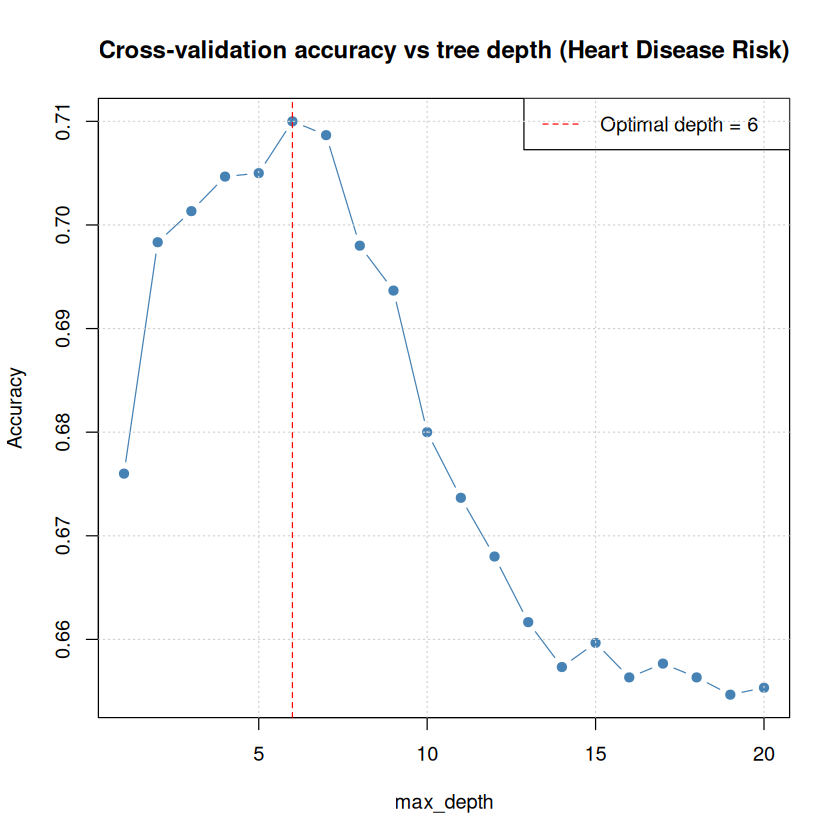

In [91]:
plot(1:20, cv_accuracy, type = "b", pch = 19, col = "steelblue",
     xlab = "max_depth", ylab = "Accuracy",
     main = "Cross-validation accuracy vs tree depth (Heart Disease Risk)")
abline(v = best_depth, col = "red", lty = 2)
legend("topright", legend = paste("Optimal depth =", best_depth), col = "red", lty = 2)
grid()

In R, the best depth is 6. The model is more complex, there is higher risk of overfitting.

In [92]:
optimal_tree <- rpart(
  Heart_Disease_Risk ~ .,
  data = cbind(X_train, Heart_Disease_Risk = Y_train),
  method = "class",
  control = rpart.control(maxdepth = best_depth, cp = 0)
)

y_pred_tree <- predict(optimal_tree, X_test, type = "class")

In [93]:
Y_test_fac  <- factor(Y_test,                    levels = c(0, 1), labels = c("Low", "High"))
y_pred_tree <- factor(as.numeric(y_pred_tree)-1, levels = c(0, 1), labels = c("Low", "High"))

cat("Niveaux y_pred_tree :", levels(y_pred_tree), "\n")
cat("Niveaux Y_test_fac  :", levels(Y_test_fac), "\n")

cm <- confusionMatrix(y_pred_tree, Y_test_fac, positive = "High")
print(cm)

Niveaux y_pred_tree : Low High 
Niveaux Y_test_fac  : Low High 
Confusion Matrix and Statistics

          Reference
Prediction  Low High
      Low  1328  536
      High  334  802
                                          
               Accuracy : 0.71            
                 95% CI : (0.6934, 0.7262)
    No Information Rate : 0.554           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4044          
                                          
 Mcnemar's Test P-Value : 9.457e-12       
                                          
            Sensitivity : 0.5994          
            Specificity : 0.7990          
         Pos Pred Value : 0.7060          
         Neg Pred Value : 0.7124          
             Prevalence : 0.4460          
         Detection Rate : 0.2673          
   Detection Prevalence : 0.3787          
      Balanced Accuracy : 0.6992          
                                          
   

The confusion matrix shows a 2x2 table:
- Top-left (True Negative): Low risk patients correctly predicted as Low risk
- Top-right (False Positive): Low risk patients wrongly predicted as High risk
- Bottom-left (False Negative): High risk patients wrongly predicted as Low risk
- Bottom-right (True Positive): High risk patients correctly predicted as High risk

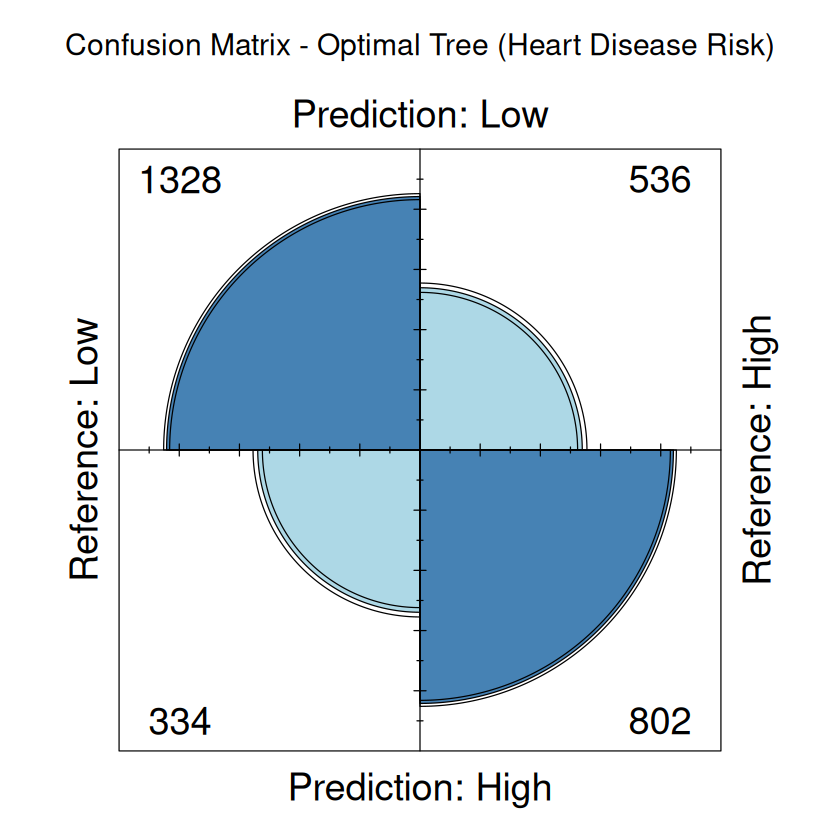

In [94]:
fourfoldplot(cm$table, color = c("lightblue", "steelblue"),
             main = "Confusion Matrix - Optimal Tree (Heart Disease Risk)")

The Confusion Matrix shows that the tree struggles (even more in R) to find the "High" Risk and identify them often as "Low". 

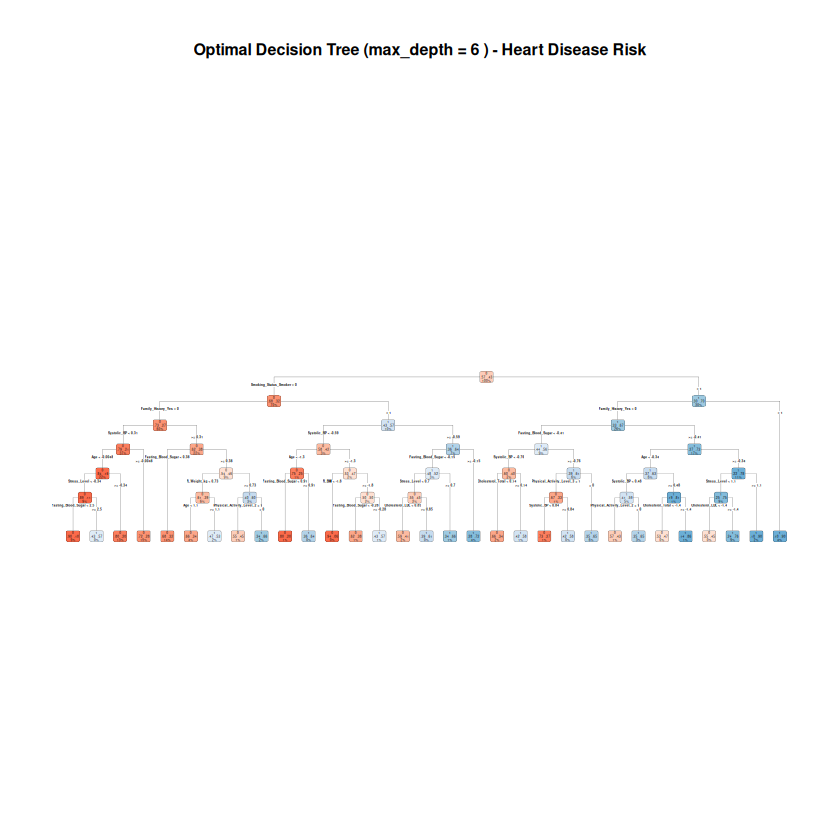

In [95]:
rpart.plot(optimal_tree, 
           type = 4, 
           extra = 104,
           fallen.leaves = TRUE,
           main = paste("Optimal Decision Tree (max_depth =", best_depth, ") - Heart Disease Risk"),
           box.palette = "RdBu")

Feature importance measures how much each variable contributed to the tree's decisions across 
all splits. It is calculated as the weighted reduction in Gini impurity that each variable 
produces when used to split a node. A higher value means the variable is more useful for 
predicting Heart Disease Risk. This is one of the key advantages of decision trees over models 
like SVM or neural networks: they are fully interpretable and show directly which variables 
drive the predictions.

Top 5 most important variables:
Smoking_Status_Smoker    Family_History_Yes           Systolic_BP 
           0.48205170            0.15635389            0.09690104 
  Fasting_Blood_Sugar                   Age 
           0.06110192            0.05307984 


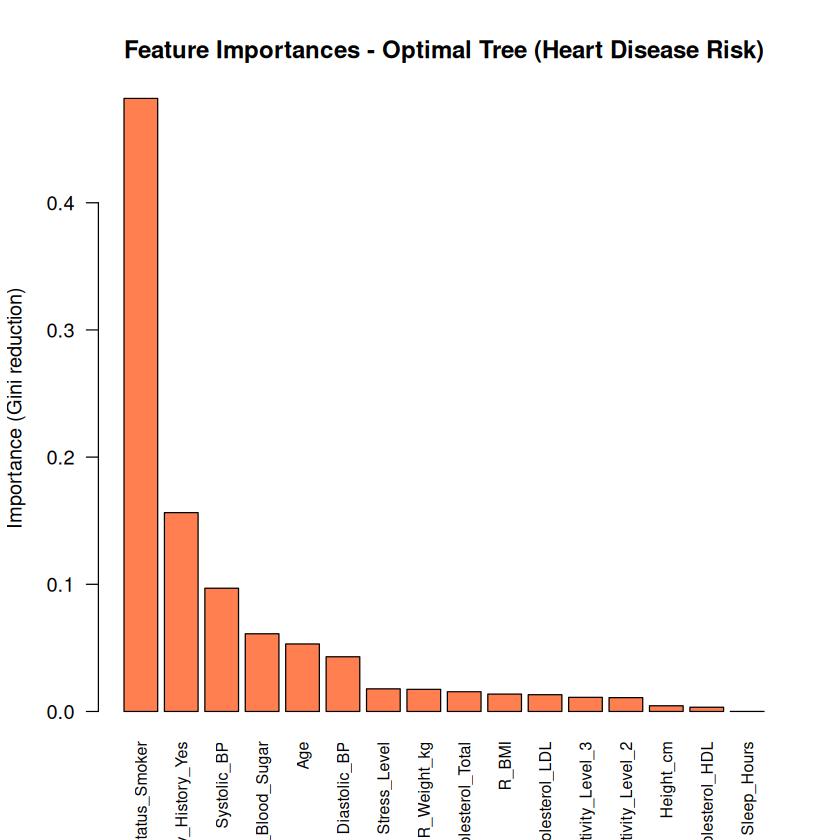

In [96]:
importances <- optimal_tree$variable.importance
importances <- sort(importances, decreasing = TRUE)
importances_pct <- importances / sum(importances)

barplot(importances_pct,
        las = 2,
        col = "coral",
        main = "Feature Importances - Optimal Tree (Heart Disease Risk)",
        ylab = "Importance (Gini reduction)",
        cex.names = 0.8)

cat("Top 5 most important variables:\n")
print(head(importances_pct, 5))


The feature importance plot confirms and reinforces what we observed in the tree visualization.
Overall, the trend is the same, but all variables have some importance, whereas in Python only four were significant.
The more levels the tree has, the more variables it uses, so this makes perfect sense. 

#### iv) Model Aggregation : Random forest

We will create a model for predicting the risk of heart disease using a random forest.

In [97]:
rf.heart <- randomForest(
    x        = X_train,
    y        = as.factor(Y_train),
    xtest    = X_test,
    ytest    = as.factor(Y_test),  # factor ici aussi
    ntree    = 500,
    do.trace = 50,
    importance = TRUE
)

attributes(rf.heart)


ntree      OOB      1      2|    Test      1      2
   50:  29.40% 21.67% 39.50%|  28.07% 19.49% 38.71%
  100:  27.97% 19.93% 38.47%|  27.57% 19.07% 38.12%
  150:  27.91% 19.62% 38.74%|  27.80% 18.83% 38.94%
  200:  27.80% 19.31% 38.89%|  27.07% 17.93% 38.42%
  250:  27.68% 19.31% 38.62%|  27.10% 18.17% 38.19%
  300:  27.70% 19.36% 38.60%|  27.27% 18.47% 38.19%
  350:  27.71% 19.31% 38.68%|  27.03% 18.05% 38.19%
  400:  27.61% 19.36% 38.39%|  27.20% 18.29% 38.27%
  450:  27.57% 19.33% 38.33%|  27.37% 18.53% 38.34%
  500:  27.49% 19.09% 38.47%|  27.20% 18.29% 38.27%


$names
 [1] "call"            "type"            "predicted"       "err.rate"       
 [5] "confusion"       "votes"           "oob.times"       "classes"        
 [9] "importance"      "importanceSD"    "localImportance" "proximity"      
[13] "ntree"           "mtry"            "forest"          "y"              
[17] "test"            "inbag"          

$class
[1] "randomForest"

To have better results, we search for the best value for mtry.

mtry = 6  OOB error = 0.186314 
Searching left ...
mtry = 4 	OOB error = 0.1861299 
0.0009880858 0.01 
Searching right ...
mtry = 9 	OOB error = 0.1866895 
-0.002015669 0.01 
  mtry  OOBError
4    4 0.1861299
6    6 0.1863140
9    9 0.1866895


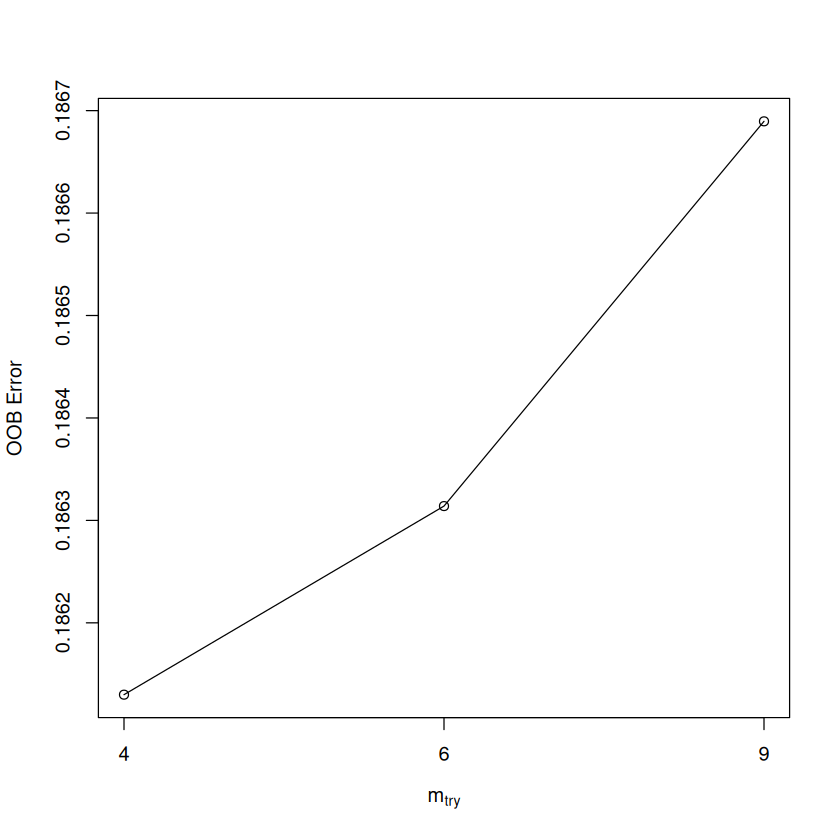

In [98]:
best_mtry <- tuneRF(X_train, Y_train, stepFactor=1.5, improve=0.01, ntreeTry=500)
print(best_mtry)

The optimal value is 4. Therefore, we need to restart the learning process.

In [99]:
rf.heart <- randomForest(
  x = X_train,
  y = as.factor(Y_train),
  xtest = X_test,
  ytest = as.factor(Y_test),
  ntree = 500,
  do.trace = 50,
  importance = TRUE,
  mtry=4
)

ntree      OOB      1      2|    Test      1      2
   50:  28.83% 20.79% 39.35%|  28.57% 19.74% 39.54%
  100:  27.89% 19.34% 39.06%|  27.43% 18.17% 38.94%
  150:  27.74% 19.40% 38.64%|  27.33% 18.35% 38.49%
  200:  27.67% 19.46% 38.39%|  27.43% 18.41% 38.64%
  250:  27.58% 19.05% 38.74%|  27.50% 18.23% 39.01%
  300:  27.58% 19.09% 38.68%|  27.23% 18.29% 38.34%
  350:  27.41% 19.20% 38.14%|  27.10% 18.41% 37.89%
  400:  27.42% 19.11% 38.27%|  27.37% 18.29% 38.64%
  450:  27.51% 19.29% 38.25%|  27.43% 18.41% 38.64%
  500:  27.39% 19.23% 38.06%|  27.33% 18.23% 38.64%


Smoking_Status_Smoker           Family_History_Yes 
                      162.07                        73.87 
                 Systolic_BP                  R_Weight_kg 
                       37.40                        30.60 
   Physical_Activity_Level_3                          Age 
                       29.34                        27.93 
         Fasting_Blood_Sugar                        R_BMI 
                       25.22                        25.02 
             Cholesterol_LDL            Cholesterol_Total 
                       24.20                        20.96 
   Physical_Activity_Level_2                 Diastolic_BP 
                       19.92                        18.77 
                   Height_cm                 Stress_Level 
                       15.16                        14.38 
                  Gender_Man    Physical_Activity_Level_1 
                       10.68                         9.14 
             Cholesterol_HDL Alcohol_Consumption_Moderate 
                        5.61                         2.26 
                 Sleep_Hours    Alcohol_Consumption_Heavy 
                        1.62                        -1.99

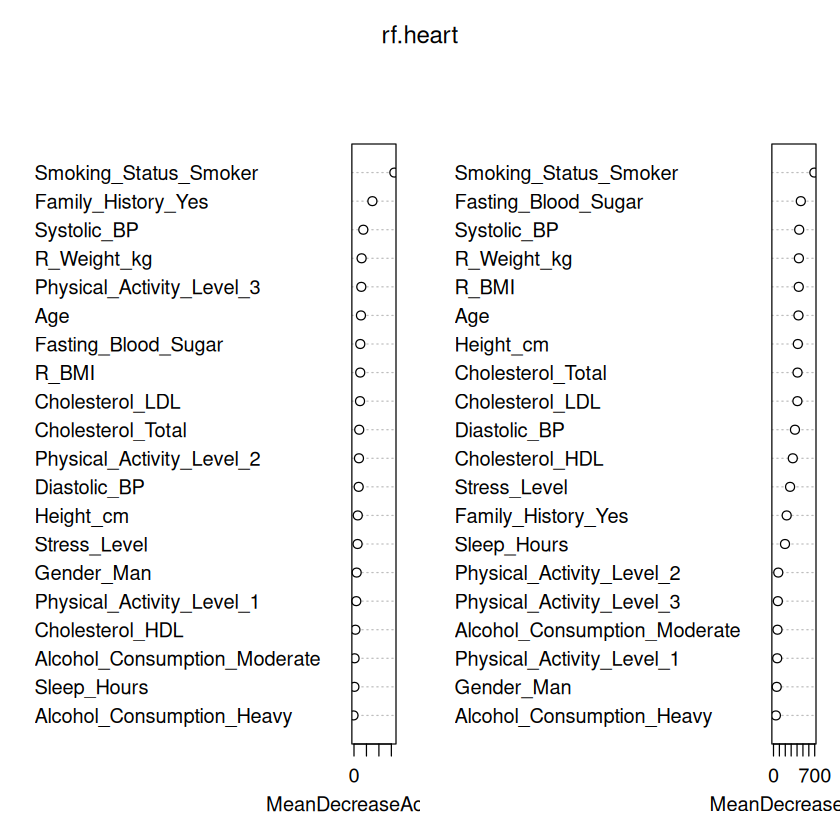

In [100]:
sort(round(importance(rf.heart)[, "MeanDecreaseAccuracy"], 2), decreasing = TRUE)
varImpPlot(rf.heart)

We observe that the variable that contributes the most is Smoking Status, which corresponds to the results of the descriptive analysis.

In [101]:
pred.heart=rf.heart$test$predicted


matrice <- table(pred.heart,Y_test)

print(matrice)

accuracy <- sum(diag(matrice)) / sum(matrice)
print(paste("Accuracy :", round(accuracy * 100, 2), "%"))

          Y_test
pred.heart    0    1
         0 1359  517
         1  303  821
[1] "Accuracy : 72.67 %"


At the end, we obtaint 73.67% of accuracy, equivalent of the obtained results in Python, with the same distribution of Fake Positive and Negative rates.

#### v) Model Aggregation : Boosting

When building an aggregation model using boosting, you can adjust the `shrinkage` parameter, which corresponds to the learning rate. More precisely, boosting is a method where new prediction trees are sequentially added to correct the errors made by all the previous trees. The shrinkage parameter controls the contribution of each new tree to the final model. Instead of adding 100% of the new tree's prediction, only a fraction is added (for example, 10% or 1%), thus limiting overfitting.
We can also adjust the `ntree` parameter, which corresponds to the final number of trees.
We will attempt to optimize these parameters through cross-validation.

Valeurs uniques : 1 0 


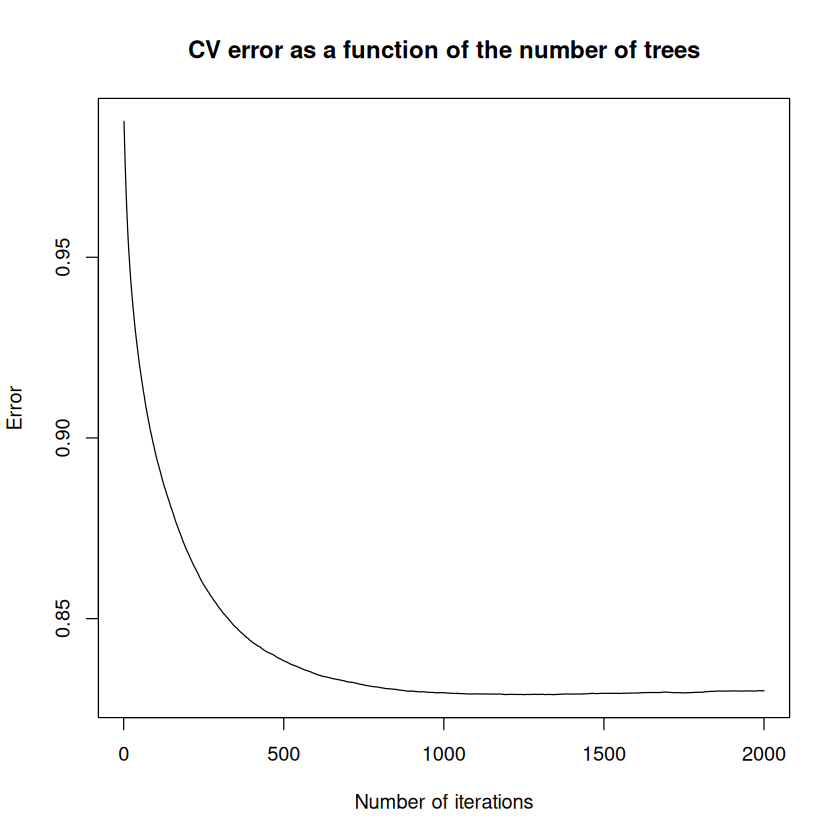

In [102]:
target_boost <- ifelse(Y_train == levels(as.factor(Y_train))[2], 1, 0)
cat("Valeurs uniques :", unique(target_boost), "\n")  # doit afficher 0 1

df_boost_train <- as.data.frame(X_train)
df_boost_train$Heart_Disease_Risk <- as.numeric(target_boost)

boost.dis <- gbm(Heart_Disease_Risk ~ ., 
                 data = df_boost_train, 
                 distribution = "adaboost", 
                 n.trees = 2000, 
                 cv.folds = 10,
                 n.minobsinnode = 5,
                 shrinkage = 0.03,
                 verbose = FALSE)


plot(boost.dis$cv.error, type = "l", 
     main = "CV error as a function of the number of trees",
     xlab = "Number of iterations", ylab = "Error")

The error is worst in R. We have a 0.85 error at 400 iterations, score obtained with only 15 iterations in Python. 

In [103]:
print(boost.dis$cv.error[1])

[1] 0.9876189


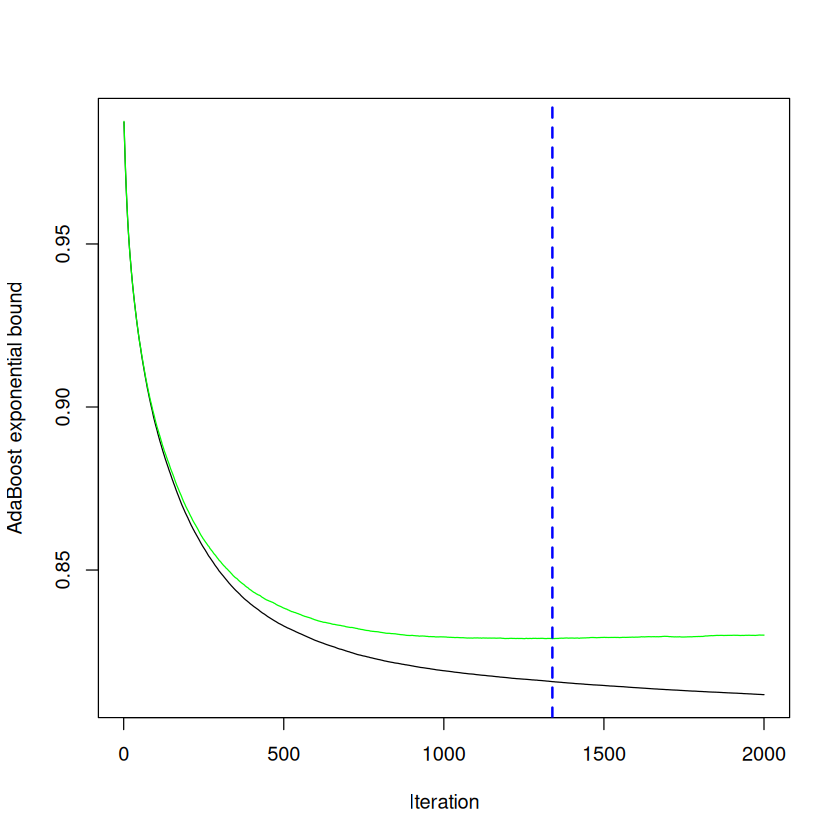

In [104]:
# optimal number of iterations 
best.ited=gbm.perf(boost.dis,method="cv")

This graph shows that the optimal number of iterations is around 1000. However, this result assumes a fixed shrinkage. Therefore, we will look for the best parameter combination in the next cell.

In [105]:
shrink_vals <- c(0.001, 0.01, 0.05, 0.1)
results <- data.frame()

for (s in shrink_vals) {
  m <- gbm(Heart_Disease_Risk ~ ., data = df_boost_train, distribution = "adaboost",
           n.trees = 1000, shrinkage = s, cv.folds = 10)
  
  best_t <- gbm.perf(m, method = "cv", plot.it = FALSE)
  results <- rbind(results, data.frame(shrinkage = s, n.trees = best_t, error = m$cv.error[best_t]))
}

best_combi=results[order(results$error), ][1, ]

In [106]:
print(best_combi)

  shrinkage n.trees     error
3      0.05     760 0.8282189


Optimizing these two parameters yields a better result: 0.83 < 0.99.

In [107]:
prob_test <- predict(boost.dis, newdata = X_test, n.trees = 307, shrinkage=0.1, type = "response")

pred_test <- ifelse(prob_test > 0.5, 1, 0)

matrice <- table(Reel = Y_test, Predi = pred_test)

print(matrice)

accuracy <- sum(diag(matrice)) / sum(matrice)
print(paste("Accuracy :", round(accuracy * 100, 2), "%"))

    Predi
Reel    0    1
   0 1386  276
   1  565  773
[1] "Accuracy : 71.97 %"


Finally, we obtaint 71.97% of accuracy, which is equivalent of the Python's accuraty.

#### vi) Neural network

In [108]:
# Données classification
df_train_classif <- as.data.frame(X_train)
df_train_classif$Heart_Disease_Risk <- as.factor(ifelse(Y_train == 1, "Risk", "NoRisk"))

df_test_classif <- as.data.frame(X_test)
df_test_classif$Heart_Disease_Risk <- as.factor(ifelse(Y_test == 1, "Risk", "NoRisk"))

In [109]:
# Train & Optimitation
set.seed(24)
control_cv_reg <- trainControl(method = "cv", number = 8, classProbs = TRUE)
grid_hiperpar_reg <- expand.grid(size = c(2, 4, 6), decay = c(0.001, 0.01, 0.05, 0.1))

tuned_nn_classifier <- train(
  Heart_Disease_Risk ~ .,
  data = df_train_classif,
  method = "nnet",
  trControl = control_cv_reg,
  tuneGrid = grid_hiperpar_reg,
  preProcess = "range",
  trace = FALSE,
  maxit = 600, 
  MaxNWts = 3000 # security cape
)

   size decay  Accuracy     Kappa  AccuracySD    KappaSD
1     2 0.001 0.7386669 0.4610770 0.006864353 0.01459362
2     2 0.010 0.7375845 0.4591380 0.008059150 0.01667752
3     2 0.050 0.7369175 0.4579268 0.008103767 0.01712754
4     2 0.100 0.7394180 0.4626919 0.008127038 0.01699485
5     4 0.001 0.7353352 0.4538791 0.010494952 0.02206287
6     4 0.010 0.7365009 0.4564115 0.008702814 0.01832410
7     4 0.050 0.7355844 0.4554472 0.009489076 0.02009147
8     4 0.100 0.7368338 0.4575444 0.007176187 0.01526395
9     6 0.001 0.7295000 0.4425133 0.011233844 0.02387947
10    6 0.010 0.7317512 0.4470600 0.009423891 0.01965764
11    6 0.050 0.7364174 0.4569868 0.008315107 0.01789111
12    6 0.100 0.7347511 0.4535251 0.009864836 0.02025818
[1] " "
[1] "Optimal parameters"
[1] "####################"
  size decay
4    2   0.1


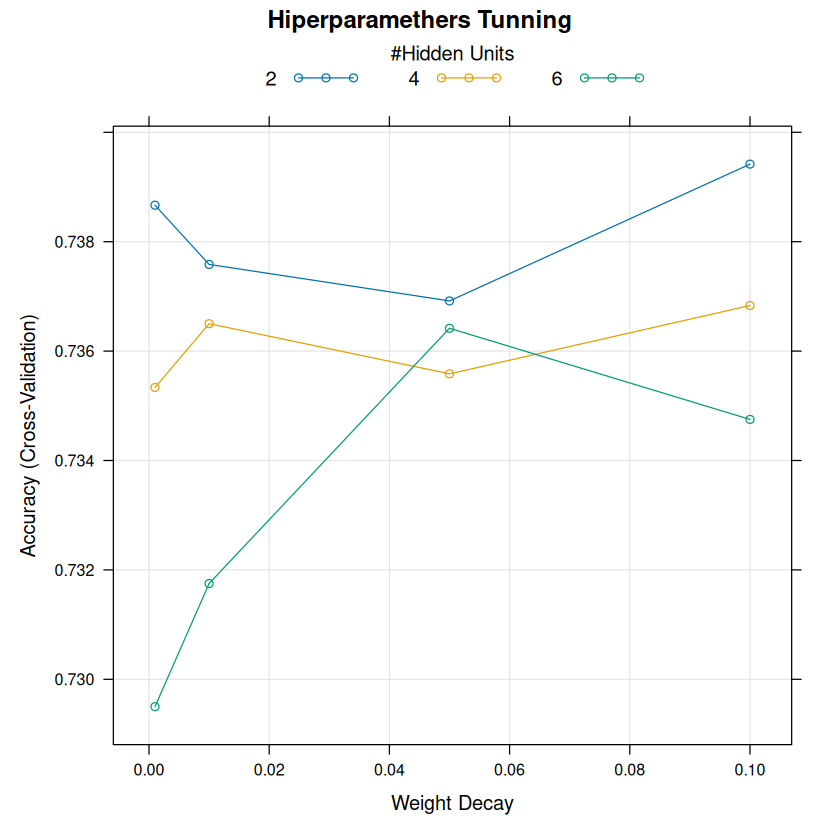

In [110]:
# Compute metrics
print(tuned_nn_classifier$results)
print(" ")
print("Optimal parameters")
print("####################")
print(tuned_nn_classifier$bestTune)
plot(tuned_nn_classifier, main = "Hiperparamethers Tunning")

In [111]:
# Final predictions for the test sample
preds_cls_clase <- predict(tuned_nn_classifier, newdata = df_test_classif)
preds_cls_probs <- predict(tuned_nn_classifier, newdata = df_test_classif, type = "prob")

# Confusion matrix
confusionMatrix(preds_cls_clase, df_test_classif$Heart_Disease_Risk)

Confusion Matrix and Statistics

          Reference
Prediction NoRisk Risk
    NoRisk   1335  460
    Risk      327  878
                                          
               Accuracy : 0.7377          
                 95% CI : (0.7215, 0.7533)
    No Information Rate : 0.554           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4639          
                                          
 Mcnemar's Test P-Value : 2.535e-06       
                                          
            Sensitivity : 0.8032          
            Specificity : 0.6562          
         Pos Pred Value : 0.7437          
         Neg Pred Value : 0.7286          
             Prevalence : 0.5540          
         Detection Rate : 0.4450          
   Detection Prevalence : 0.5983          
      Balanced Accuracy : 0.7297          
                                          
       'Positive' Class : NoRisk          
                  

The neural network model is similar than the Python one. It is optimized using cross-validation and achieves an accuracy of 73.7% on the test set, with a balanced accuracy of 72.9% and a Kappa coefficient of 0.46. The best architecture corresponds to a simple network with 2 hidden neurons and low regularization (decay = 0.001), suggesting that the relationship between the explanatory variables and cardiovascular risk does not require a complex architecture.

The model shows a better ability to identify individuals without cardiovascular risk (sensitivity 80.3%) than those at risk (specificity 65.5%). This result is medically significant, as false negatives can have clinically relevant consequences.

### c) Comparison of forecasting models

#### i- ROC curve

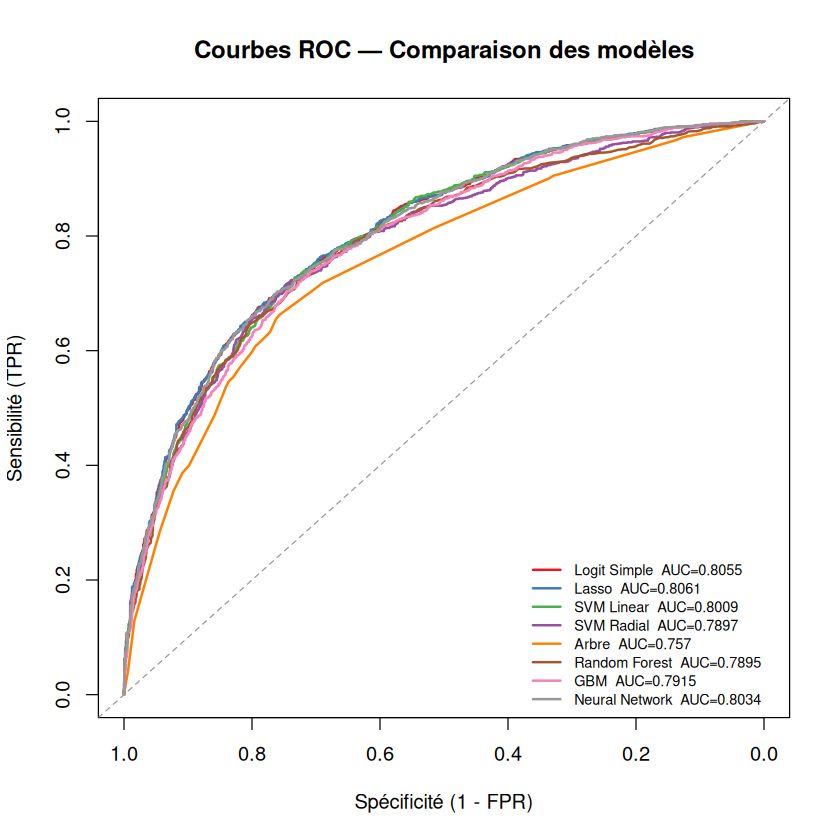

In [123]:

# Régression logistique simple
prob_logit <- predict(logit_simple, newdata = X_test, type = "response")

# Lasso
prob_lasso <- as.vector(predict(cv_lasso, newx = as.matrix(X_test), 
                                s = "lambda.min", type = "response"))

# SVM Linéaire
prob_svm_lin <- attr(predict(svm_lin_best, newdata = as.matrix(X_test),
                             probability = TRUE),
                     "probabilities")[, "1"]

# SVM Radial
prob_svm_rad <- attr(predict(best_svm, newdata = as.matrix(X_test),
                             probability = TRUE), "probabilities")[, "1"]

# Arbre de décision
prob_tree <- predict(optimal_tree, X_test, type = "prob")[, "1"]

# Random Forest
prob_rf <- rf.heart$test$votes[, "1"]

# GBM Boosting
prob_gbm <- predict(boost.dis, newdata = X_test, 
                    n.trees = 307, type = "response")

preds_cls_probs <- predict(tuned_nn_classifier, newdata = df_test_classif, type = "prob")


Y_ref <- as.numeric(as.character(Y_test))  # 0/1 numérique

# ---- Construction des ROC ----
modeles <- list(
  "Logit Simple"  = prob_logit,
  "Lasso"         = prob_lasso,
  "SVM Linear" = prob_svm_lin,
  "SVM Radial"    = prob_svm_rad,
  "Arbre"         = prob_tree,
  "Random Forest" = prob_rf,
  "GBM"           = prob_gbm,
  "Neural Network" = preds_cls_probs[, "Risk"]
)

couleurs <- c("#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00",
              "#A65628", "#F781BF", "#999999", "#66C2A5", "#FC8D62", "#8DA0CB")

# ---- Graphique ----
plot(NULL, xlim = c(1, 0), ylim = c(0, 1),
     xlab = "Spécificité (1 - FPR)", 
     ylab = "Sensibilité (TPR)",
     main = "Courbes ROC — Comparaison des modèles")
abline(a = 1, b = -1, lty = 2, col = "grey60")

auc_vals <- c()
for(i in seq_along(modeles)) {
  roc_i    <- roc(Y_ref, modeles[[i]], quiet = TRUE)
  auc_i    <- round(auc(roc_i), 4)
  auc_vals <- c(auc_vals, auc_i)
  plot(roc_i, add = TRUE, col = couleurs[i], lwd = 2)
}

legend("bottomright",
       legend = paste0(names(modeles), "  AUC=", auc_vals),
       col    = couleurs,
       lwd    = 2,
       cex    = 0.72,
       bty    = "n")

#### ii- Forecasting models using other criterias

In [138]:

results <- lapply(names(modeles), function(name) {
  y_prob <- modeles[[name]]
  y_pred <- as.numeric(y_prob >= 0.5)

  data.frame(
    Model     = name,
    Accuracy   = Accuracy(y_pred, Y_ref),
    Error    = 1 - Accuracy(y_pred, Y_ref),
    F1_score   = F1_Score(Y_ref, y_pred, positive = 1),
    Precision  = Precision(Y_ref, y_pred, positive = 1),
    Recall     = Recall(Y_ref, y_pred, positive = 1),
    AUC_ROC    = as.numeric(auc(roc(Y_ref, y_prob, quiet = TRUE))),
    Brier      = mean((y_prob - Y_ref)^2)
  )
})

df_results <- do.call(rbind, results)
rownames(df_results) <- df_results$Model
df_results$Model    <- NULL
df_results           <- round(df_results, 4)

formattable(df_results, list(
  Accuracy  = color_tile("white"),
  F1_score  = color_tile("white"),
  Precision = color_tile("white"),
  Recall   = color_tile("white"),
  AUC_ROC   = color_tile("white"),
  Error    = color_tile("white"),
  Brier     = color_tile("white")
))

  Brier     = color_tile("white")
best_high <- c("Accuracy", "F1_score", "Precision", "Recall", "AUC_ROC")
best_low  <- c("Error", "Brier")

cat("\n── Meilleurs modèles ──\n")
for (col in c(best_high, best_low)) {
  if (col %in% best_high) best_row <- which.max(df_results[[col]])
  else                     best_row <- which.min(df_results[[col]])
  cat(sprintf("%-12s : %s (%.4f)\n", col, rownames(df_results)[best_row], df_results[best_row, col]))
}

,Accuracy,Error,F1_score,Precision,Recall,AUC_ROC,Brier
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Logit Simple,0.7360,0.2640,0.6870,0.7290,0.6495,0.8055,0.1779
Lasso,0.7387,0.2613,0.6886,0.7347,0.6480,0.8061,0.1776
SVM Linear,0.7283,0.2717,0.6726,0.7272,0.6256,0.8009,0.1812
SVM Radial,0.7320,0.2680,0.6734,0.7375,0.6196,0.7897,0.1853
Arbre,0.7100,0.2900,0.6483,0.7060,0.5994,0.7570,0.1970
Random Forest,0.7290,0.2710,0.6707,0.7321,0.6188,0.7895,0.1856
GBM,0.7197,0.2803,0.6477,0.7369,0.5777,0.7915,0.1871
Neural Network,0.7377,0.2623,0.6905,0.7286,0.6562,0.8034,0.1789



── Meilleurs modèles ──
Accuracy     : Lasso (0.7387)
F1_score     : Neural Network (0.6905)
Precision    : SVM Radial (0.7375)
Recall       : Neural Network (0.6562)
AUC_ROC      : Lasso (0.8061)
Error        : Lasso (0.2613)
Brier        : Lasso (0.1776)


The top-performing models across all metrics are Lasso and Neural Networks. The radial SVM, despite its high Precision, fails to meet our contextual needs. Because our priority is to minimize False Negatives (maximizing Recall), a higher False Positive rate is preferable, which make not the SVM a good model.

The results are really close in Python and in R (some differences at $10^-3$). 

## 3. Prédiction of Cholesterol_LDL

Repeat the previous steps to predict the variable Cholesterol_LDL from all the other variables (except the
variable Heart_Disease_Risk).

### a. Creation of training sample and a test sample

In [ ]:
train_idx <- read.csv("train_indices.csv")$index
test_idx <- read.csv("test_indices.csv")$index

train_idx_r <- train_idx + 1
test_idx_r <- test_idx + 1

df_train <- df[train_idx_r, ]
df_test <- df[test_idx_r, ]

set.seed(42)

In [ ]:
XC_train <- df_train[, !(names(df_train) %in% c("Patient_ID", "Heart_Disease_Risk", "Cholesterol_LDL"))]
YC_train <- df_train$Cholesterol_LDL

XC_test <- df_test[, !(names(df_test) %in% c("Patient_ID", "Heart_Disease_Risk","Cholesterol_LDL"))]
YC_test <- df_test$Cholesterol_LDL

quanti <- c("Age", "Height_cm", "R_Weight_kg", "R_BMI", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", "Cholesterol_HDL", "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

XC_train_scaled <- scale(XC_train[, quanti])
XC_test[, quanti] <- scale(XC_test[, quanti], 
                          center = attr(XC_train_scaled, "scaled:center"), 
                          scale  = attr(XC_train_scaled, "scaled:scale"))
XC_train[, quanti] <- XC_train_scaled

XC_train <- dummy_cols(XC_train, 
                               select_columns = c("Stress_Level"), # On force la sélection ici
                               remove_first_dummy = TRUE, 
                               remove_selected_columns = TRUE)
XC_test <- dummy_cols(XC_test, 
                               select_columns = c("Stress_Level"), # On force la sélection ici
                               remove_first_dummy = TRUE, 
                               remove_selected_columns = TRUE)

XC_test<-XC_test[, colnames(XC_train)]

### b. Comparison of forecasting models

Before we begin, we retrieved the gplot.res function, which allows us to plot the residual graph with fixed colors and scales on the axes. This will highlight the effectiveness of the models that will follow.

In [ ]:
gplot.res <- function(x, y, xmin, xmax, ymin, ymax, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(xmin, xmax)+ylim(ymin, ymax)+
    ylab("Residues")+ xlab("Predicted values")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

#### i) Linear model

In [ ]:
# glmnet: glm seen in the S1
lasso_cv <- cv.glmnet(as.matrix(XC_train), YC_train, 
                      family = "gaussian", #to predict a continuous value
                      alpha = 1, #lasso
                      nfolds = 10)

cat(sprintf("Best lambda found : %.6f\n", lasso_cv$lambda.min))

Best lambda found : 0.128669


In [ ]:
# Predictions
y_pred_lasso <- as.vector(predict(lasso_cv, newx = as.matrix(XC_test), s = "lambda.min"))

# Calcul of the metrics
mse_lasso  <- mean((YC_test - y_pred_lasso)^2)
rmse_lasso <- sqrt(mse_lasso)
mae_lasso  <- mean(abs(YC_test - y_pred_lasso))

# Calcul of R²
rss <- sum((y_pred_lasso - YC_test)^2)
tss <- sum((YC_test - mean(YC_test))^2)
r2_lasso <- 1 - (rss/tss)

cat("===Results of Lasso ===\n")
cat(sprintf("Best lambda : %.6f\n", lasso_cv$lambda.min))
cat(sprintf("RMSE : %.2f mg/dL\n", rmse_lasso))
cat(sprintf("MAE  : %.2f mg/dL\n", mae_lasso))
cat(sprintf("R²   : %.4f\n", r2_lasso))

===Results of Lasso ===
Best lambda : 0.128669
RMSE : 9.97 mg/dL
MAE  : 7.95 mg/dL
R²   : 0.6972


The results of Lasso selection are quite similar to those of Python.

Lasso keeps 4 variables and deletes 15 of them 
 [1] "Height_cm"                       "R_Weight_kg"                    
 [3] "R_BMI"                           "Diastolic_BP"                   
 [5] "Cholesterol_HDL"                 "Fasting_Blood_Sugar"            
 [7] "Sleep_Hours"                     "Stress_Level_-0.514607744060628"
 [9] "Stress_Level_-0.862688062460241" "Stress_Level_-1.21076838085985" 
[11] "Stress_Level_-1.55884869925947"  "Stress_Level_0.529633211138211" 
[13] "Stress_Level_0.877713529537824"  "Stress_Level_1.22579384793744"  
[15] "Stress_Level_1.57387416633705"  


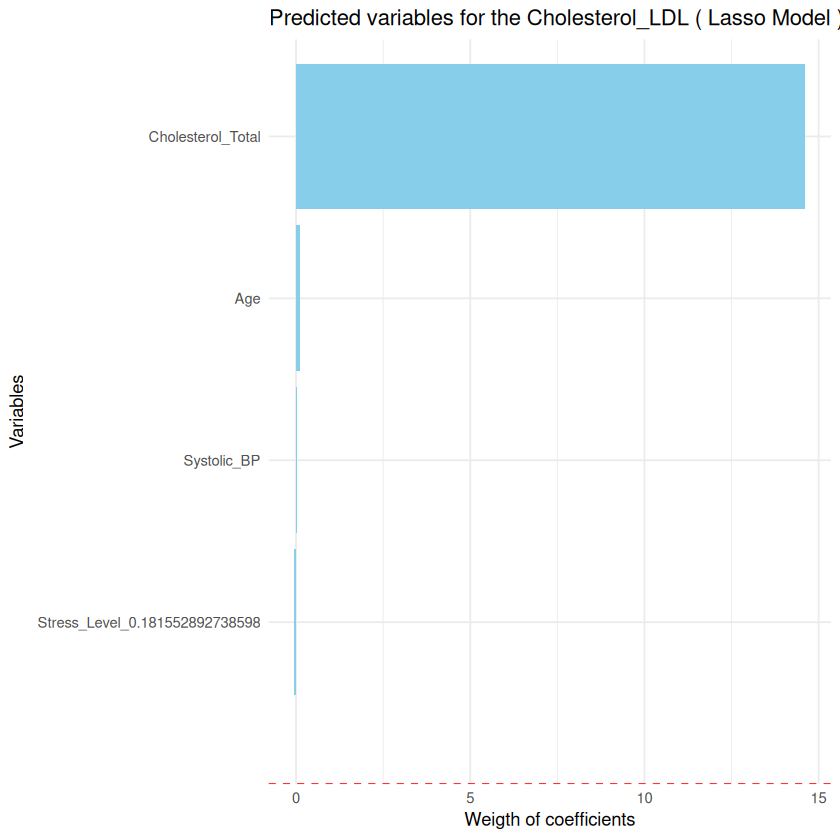

In [ ]:
# extraction and cleaning of coefficients
coef_lasso <- coef(lasso_cv, s = "lambda.min")
df_coef <- data.frame(
  Variable = rownames(coef_lasso),
  Coeff = as.vector(coef_lasso)
) %>% filter(Variable != "(Intercept)")

# Variables deleted
variables_supprimees <- df_coef %>% filter(Coeff == 0) %>% pull(Variable)
cat("Lasso keeps", sum(df_coef$Coeff != 0), "variables and deletes", length(variables_supprimees), "of them \n")
print(variables_supprimees)

# Graph
df_plot <- df_coef %>% filter(Coeff != 0) %>% arrange(Coeff)

ggplot(df_plot, aes(x = reorder(Variable, Coeff), y = Coeff)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed") +
  coord_flip() +
  labs(title = "Predicted variables for the Cholesterol_LDL ( Lasso Model )",
       x = "Variables", y = "Weigth of coefficients") +
  theme_minimal()

In [ ]:
set.seed(42)
lasso_s <- cv.glmnet(as.matrix(XC_train), YC_train, 
                     family = "gaussian", 
                     alpha = 1, 
                     nfolds = 10)

cat(sprintf("Meilleur lambda trouvé : %.6f\n", lasso_s$lambda.min))

Meilleur lambda trouvé : 0.141214


In [ ]:
y_pred_s <- as.vector(predict(lasso_s, newx = as.matrix(XC_test), s = "lambda.min"))

mse_s  <- mean((YC_test - y_pred_s)^2)
rmse_s <- sqrt(mse_s)
mae_s  <- mean(abs(YC_test - y_pred_s))
r2_s   <- 1 - (sum((y_pred_s - YC_test)^2) / sum((YC_test - mean(YC_test))^2))

cat("=== Lasso Results(ss_total) ===\n")
cat(sprintf("Best lambda : %.6f\n", lasso_s$lambda.min))
cat(sprintf("RMSE : %.2f mg/dL\n", rmse_s))
cat(sprintf("MAE  : %.2f mg/dL\n", mae_s))
cat(sprintf("R²   : %.4f\n", r2_s))

=== Lasso Results(ss_total) ===
Best lambda : 0.141214
RMSE : 9.97 mg/dL
MAE  : 7.95 mg/dL
R²   : 0.6972


Lasso keeps 4 variables et delets 15 of them 
 [1] "Height_cm"                       "R_Weight_kg"                    
 [3] "R_BMI"                           "Diastolic_BP"                   
 [5] "Cholesterol_HDL"                 "Fasting_Blood_Sugar"            
 [7] "Sleep_Hours"                     "Stress_Level_-0.514607744060628"
 [9] "Stress_Level_-0.862688062460241" "Stress_Level_-1.21076838085985" 
[11] "Stress_Level_-1.55884869925947"  "Stress_Level_0.529633211138211" 
[13] "Stress_Level_0.877713529537824"  "Stress_Level_1.22579384793744"  
[15] "Stress_Level_1.57387416633705"  


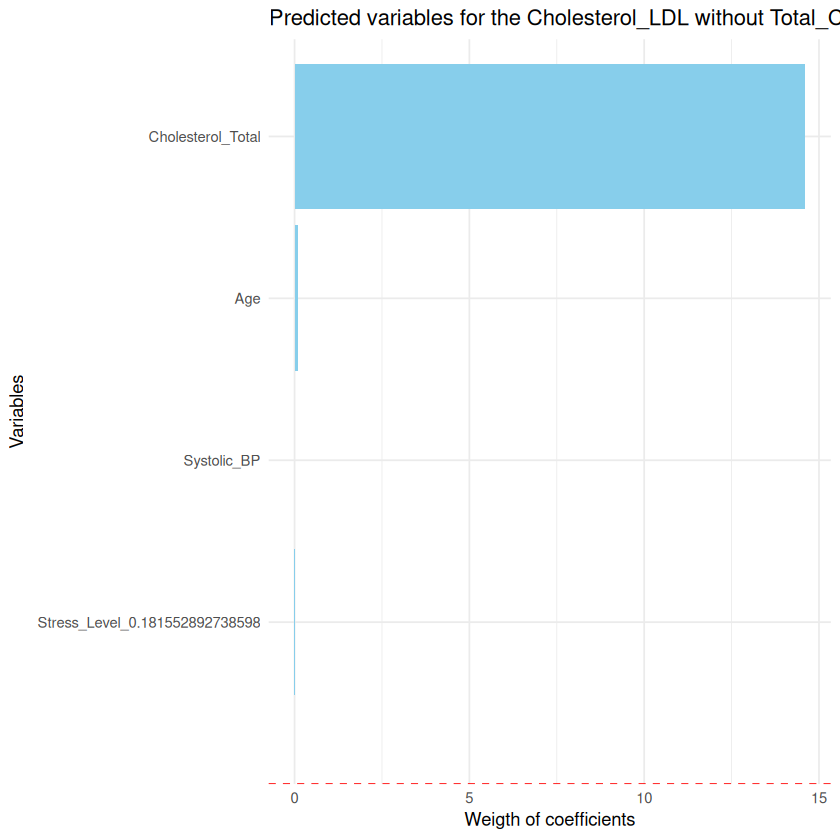

In [ ]:
coef_s <- coef(lasso_s, s = "lambda.min")
df_coef_s <- data.frame(
  Variable = rownames(coef_s),
  Coeff = as.vector(coef_s)
) %>% filter(Variable != "(Intercept)")

cat("Lasso keeps", sum(df_coef_s$Coeff != 0), "variables et delets", sum(df_coef_s$Coeff == 0), "of them", "\n")
print(df_coef_s$Variable[df_coef_s$Coeff == 0])

df_plot_s <- df_coef_s %>% filter(Coeff != 0) %>% arrange(Coeff)

ggplot(df_plot_s, aes(x = reorder(Variable, Coeff), y = Coeff)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed") +
  coord_flip() +
  labs(title = "Predicted variables for the Cholesterol_LDL without Total_Cholesterol ( Lasso Model )",
       x = "Variables", y = "Weigth of coefficients") +
  theme_minimal()

It manages to delete 15 variables which is 1 less than the one on Python.

#### ii)  SVR

Optimizing the parameters of an SVR is very time-consuming. Therefore, we decided to parallelize the searches and perform only 4 simulations for each of the 3 kernels tested.

In [ ]:
cl <- makePSOCKcluster(detectCores() - 1)
registerDoParallel(cl)


control <- trainControl(method = "cv", number = 5, allowParallel = TRUE)

set.seed(42)
model_parallel <- train(
  x = as.matrix(XC_train),
  y = YC_train,
  method = "svmRadial", # ou "svmLinear", ou "svmPoly"
  trControl = control,
  tuneLength = 4
)

stopCluster(cl)

print(model_parallel)

Support Vector Machines with Radial Basis Function Kernel 

12000 samples
   19 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 9600, 9600, 9601, 9599, 9600 
Resampling results across tuning parameters:

  C     RMSE      Rsquared   MAE     
  0.25  10.25680  0.6706568  8.150282
  0.50  10.23728  0.6716596  8.135425
  1.00  10.25534  0.6704862  8.151487
  2.00  10.31491  0.6668303  8.199198

Tuning parameter 'sigma' was held constant at a value of 0.03192444
RMSE was used to select the optimal model using the smallest value.
The final values used for the model were sigma = 0.03192444 and C = 0.5.


In [ ]:
cl <- makePSOCKcluster(detectCores() - 1)
registerDoParallel(cl)


control <- trainControl(method = "cv", number = 5, allowParallel = TRUE)

set.seed(42)
model_parallel <- train(
  x = as.matrix(XC_train),
  y = YC_train,
  method = "svmLinear",
  trControl = control,
  tuneLength = 4
)

stopCluster(cl)

print(model_parallel)

Support Vector Machines with Linear Kernel 

12000 samples
   19 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 9600, 9600, 9601, 9599, 9600 
Resampling results:

  RMSE      Rsquared   MAE     
  10.02345  0.6851328  7.971643

Tuning parameter 'C' was held constant at a value of 1


In [ ]:
cl <- makePSOCKcluster(detectCores() - 1)
registerDoParallel(cl)

control <- trainControl(method = "cv", number = 5, allowParallel = TRUE)

grid_poly_super_light <- expand.grid(
  degree = 2,
  scale = 0.1,
  C = c(1, 10)
)

set.seed(42)
model_parallel <- train(
  x = as.matrix(XC_train),
  y = YC_train,
  method = "svmPoly",
  trControl = control,
  tuneGrid = grid_poly_super_light
)

stopCluster(cl)
print(model_parallel)

Support Vector Machines with Polynomial Kernel 

12000 samples
   21 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 9600, 9600, 9601, 9599, 9600 
Resampling results across tuning parameters:

  C   RMSE      Rsquared   MAE     
   1  10.17630  0.6755468  8.106875
  10  10.19238  0.6745455  8.120058

Tuning parameter 'degree' was held constant at a value of 2
Tuning
 parameter 'scale' was held constant at a value of 0.1
RMSE was used to select the optimal model using the smallest value.
The final values used for the model were degree = 2, scale = 0.1 and C = 1.


The best results are obtained for a linear kernel and with C=1. We now train our model with these parameters.

In [ ]:
best_svr_model <- svm(x = as.matrix(XC_train), 
                      y = YC_train, 
                      kernel = "linear", 
                      cost = 1,
                      epsilon = 0.1) 

In [ ]:
y_pred_ldl <- predict(best_svr_model, newdata = as.matrix(XC_test))

mse_final  <- mean((YC_test - y_pred_ldl)^2)
rmse_final <- sqrt(mse_final)
mae_final  <- mean(abs(YC_test - y_pred_ldl))

rss_f <- sum((y_pred_ldl - YC_test)^2)
tss_f <- sum((YC_test - mean(YC_test))^2)
r2_final <- 1 - (rss_f / tss_f)


cat(sprintf("RMSE : %.2f mg/dL\n", rmse_final))
cat(sprintf("MAE  : %.2f mg/dL\n", mae_final))
cat(sprintf("R²   : %.4f\n", r2_final))

RMSE : 9.98 mg/dL
MAE  : 7.97 mg/dL
R²   : 0.6965


Results are similar to the one optaint in Python.

#### iii) Optimal tree

For Cholesterol LDL prediction we use a Decision Tree Regressor because Cholesterol LDL is a continuous numerical variable (mg/dL). The logic is the same as the classifier: the tree splits the data based on rules, but now each leaf predicts a numerical value (the average LDL of all patients in that leaf) instead of a class.

In [ ]:
cv_r2 <- c()

for (d in 1:20) {
  tree_d <- rpart(
    Cholesterol_LDL ~ .,
    data = cbind(XC_train, Cholesterol_LDL = YC_train),
    method = "anova",
    control = rpart.control(maxdepth = d, cp = 0)
  )
  pred_d <- predict(tree_d, XC_test)
  ss_res <- sum((YC_test - pred_d)^2)
  ss_tot <- sum((YC_test - mean(YC_test))^2)
  r2 <- 1 - ss_res / ss_tot
  cv_r2 <- c(cv_r2, r2)
}

best_depth_reg <- which.max(cv_r2)
cat("Best max_depth :", best_depth_reg, "\n")
cat("Best R² :", round(max(cv_r2), 4), "\n")

Best max_depth : 5 
Best R² : 0.6931 


This plot shows the cross-validation R² for each depth tested.

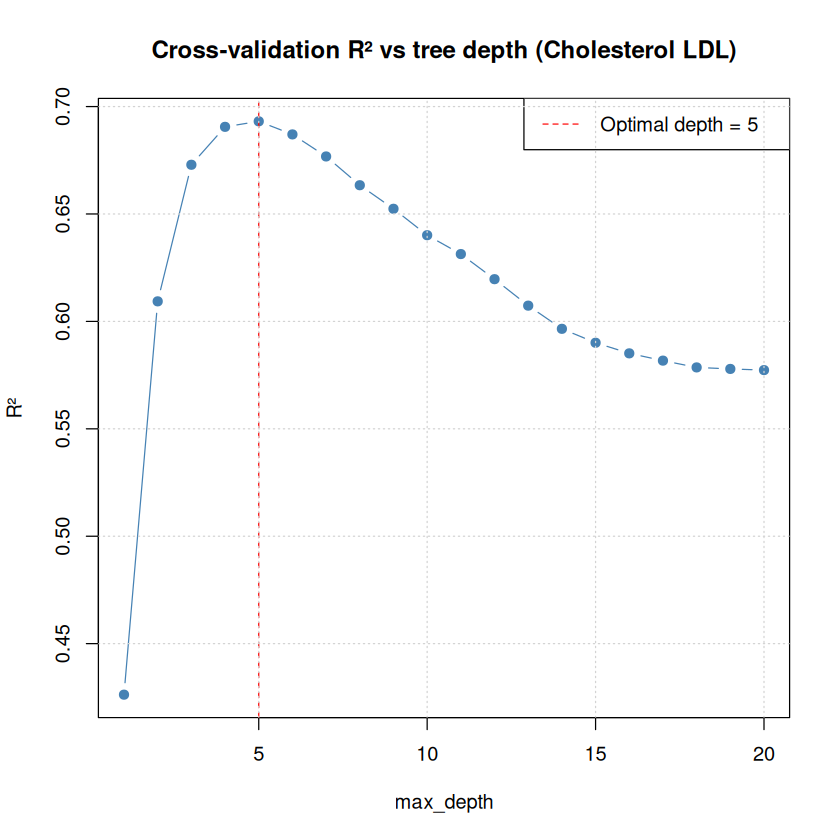

In [ ]:
plot(1:20, cv_r2, type = "b", pch = 19, col = "steelblue",
     xlab = "max_depth", ylab = "R²",
     main = "Cross-validation R² vs tree depth (Cholesterol LDL)")
abline(v = best_depth_reg, col = "red", lty = 2)
legend("topright", legend = paste("Optimal depth =", best_depth_reg), col = "red", lty = 2)
grid()

We obtaint a max_depth of 5. It the same results in Python. We train the final regression tree using the optimal depth found above. For regression, instead 
of predicting a class, each leaf of the tree predicts the average Cholesterol LDL value of all 
training patients that fall into that leaf. We evaluate the model using three metrics:

In [ ]:
optimal_tree_reg <- rpart(
  Cholesterol_LDL ~ .,
  data = cbind(XC_train, Cholesterol_LDL = YC_train),
  method = "anova",
  control = rpart.control(maxdepth = best_depth_reg, cp = 0)
)

y_pred_tree_ldl <- predict(optimal_tree_reg, XC_test)

rmse <- sqrt(mean((YC_test - y_pred_tree_ldl)^2))
mae  <- mean(abs(YC_test - y_pred_tree_ldl))
r2   <- 1 - sum((YC_test - y_pred_tree_ldl)^2) / sum((YC_test - mean(YC_test))^2)

cat("=== Optimal Decision Tree - Cholesterol LDL ===\n")
cat("RMSE :", round(rmse, 2), "mg/dL\n")
cat("MAE  :", round(mae, 2), "mg/dL\n")
cat("R²   :", round(r2, 4), "\n")

=== Optimal Decision Tree - Cholesterol LDL ===
RMSE : 10.04 mg/dL
MAE  : 7.99 mg/dL
R²   : 0.6931 


***Results***

The optimal regression tree achieves the following performance on the test set:

- **R² = 0.6924:** the model explains 69.24% of the variance in Cholesterol LDL, which is consistent with the cross-validation result. This confirms that the model generalizes well and does not overfit.

- **RMSE = 10.05 mg/dL:** on average, the model's predictions deviate by about 10.05 mg/dL from the true Cholesterol LDL value. Given that the normal LDL range is approximately 70-190 mg/dL, which is acceptable.

- **MAE = 8.01 mg/dL:** the median prediction error is even lower at 8.01 mg/dL, suggesting that most predictions are quite close to the true value, with only a few larger errors pulling the RMSE up.

Overall, the regression tree provides a solid and interpretable model for predicting Cholesterol LDL, with performance comparable to more complex models.

A residual plot shows the difference between the true and predicted Cholesterol LDL values 
(residuals) against the predicted values. In a good model, the residuals should be randomly 
scattered around zero with no visible pattern. If we see a pattern, it means the model is 
systematically missing something and could be improved.

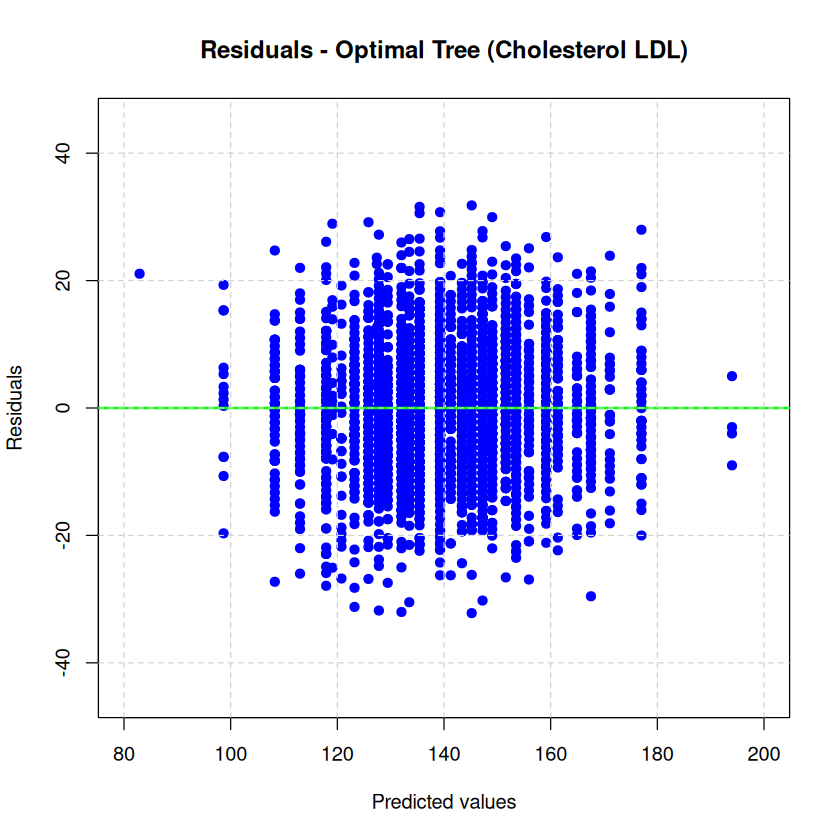

In [ ]:
res_tree <- YC_test - y_pred_tree_ldl

plot(y_pred_tree_ldl, res_tree,
     xlab = "Predicted values", ylab = "Residuals",
     main = "Residuals - Optimal Tree (Cholesterol LDL)",
     col = "blue", pch = 19, alpha = 0.5,
     xlim = c(80, 200), ylim = c(-45, 45))
abline(h = 0, col = "green", lwd = 2)
grid(lty = "dashed")

***Interpretation - Residual Plot***

The residuals are roughly centered around zero across the full range of predicted values, 
which confirms that the model does not have a systematic bias in any particular direction.

However, the vertical columns of points are a characteristic pattern of decision tree 
regressors: since each leaf of the tree predicts a single fixed value (the average LDL 
of all training patients in that leaf), many patients receive exactly the same predicted 
value, creating these vertical stripes. This is a known limitation of decision trees 
compared to smoother models like linear regression or neural networks.

Overall the residual structure is acceptable, with no clear systematic pattern, 
confirming the R² of 0.69 obtained earlier.

Since the optimal depth allows it, we display the first 3 levels of the tree for readability. The first 3 levels show the most important splitting decisions. Very interestingly, ALL splits in the first 3 levels use only Cholesterol_Total. This makes perfect medical sense: total cholesterol is mathematically the sum of LDL, HDL and other components, so it is by far the strongest predictor of LDL. Each node shows the variable and threshold used to split, the squared error, the number of samples, and the predicted LDL value for that node.

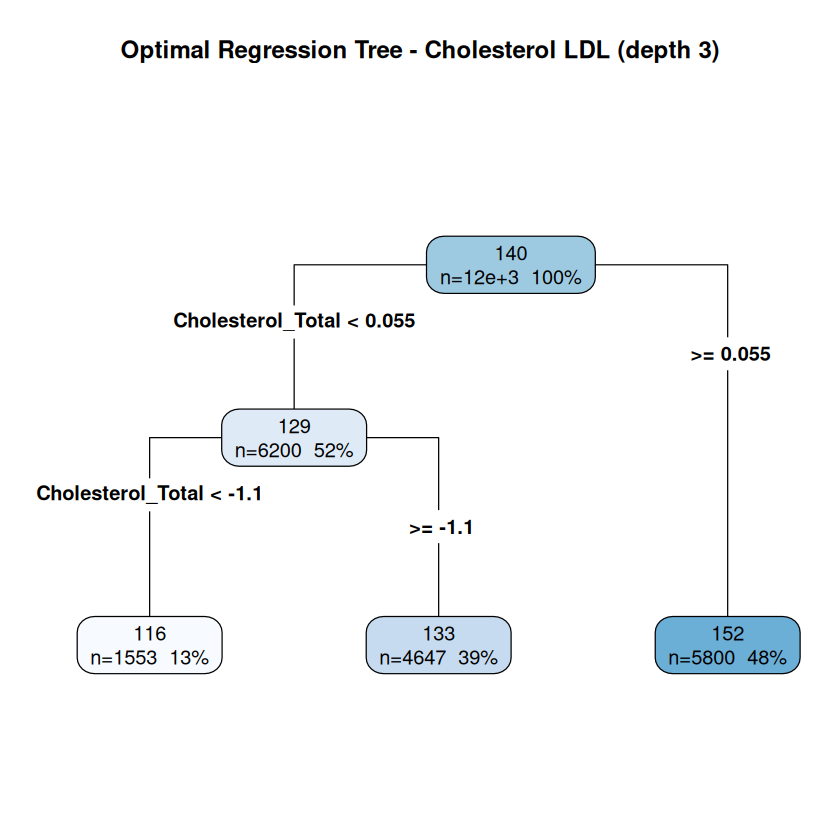

In [ ]:

tree_display <- prune(optimal_tree_reg, 
                      cp = optimal_tree_reg$cptable[3, "CP"])

rpart.plot(tree_display,
           type = 4,
           extra = 101,
           fallen.leaves = TRUE,
           main = "Optimal Regression Tree - Cholesterol LDL (depth 3)",
           box.palette = "auto")

Feature importance measures how much each variable contributed to the tree's decisions across 
all splits. It is calculated as the weighted reduction in squared error that each variable 
produces across all splits of the tree. As we already observed in the tree visualization, we 
expect Cholesterol_Total to completely dominate the importance ranking, since it was the only 
variable used in the first levels of the tree.

Top 5 most important variables:
Cholesterol_Total               Age             R_BMI       Systolic_BP 
       0.70052347        0.11604337        0.05198511        0.05057506 
      R_Weight_kg 
       0.04258650 


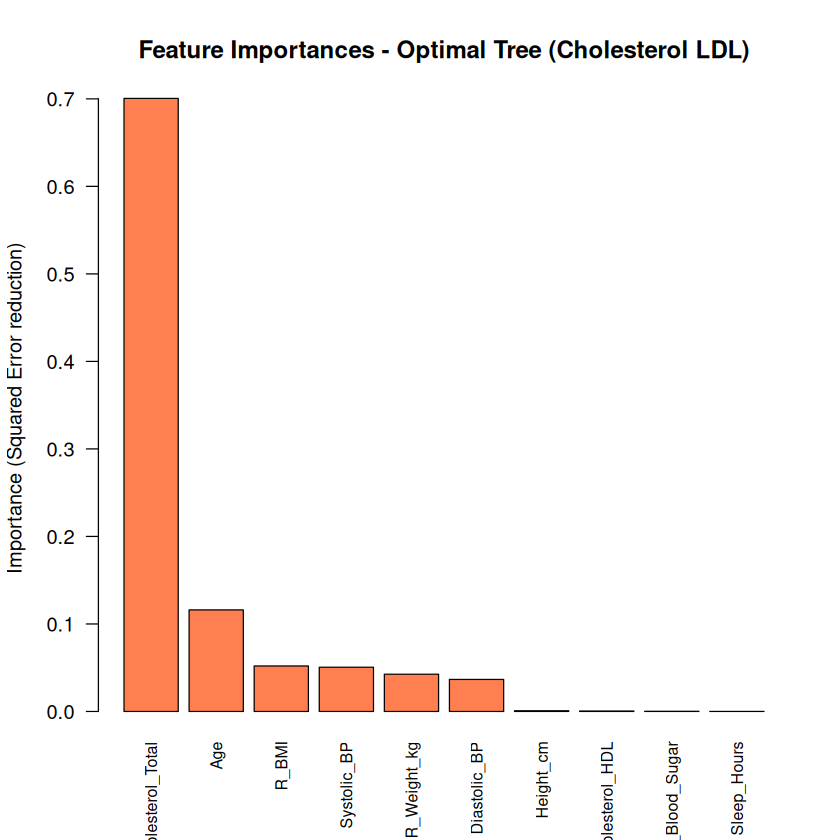

In [ ]:
importances_reg <- optimal_tree_reg$variable.importance
importances_reg <- sort(importances_reg, decreasing = TRUE)
importances_reg_pct <- importances_reg/sum(importances_reg)

barplot(importances_reg_pct,
        las = 2,
        col = "coral",
        main = "Feature Importances - Optimal Tree (Cholesterol LDL)",
        ylab = "Importance (Squared Error reduction)",
        cex.names = 0.8)

cat("Top 5 most important variables:\n")
print(head(importances_reg_pct, 5))

***Interpretation - Feature Importances***

The feature importance plot reveals an extremely clear result:

- **Cholesterol_Total (0.70):** virtually the only variable used by the tree to predict Cholesterol LDL. This is not surprising from a medical standpoint: total cholesterol is defined as the sum of LDL, HDL and VLDL cholesterol, so it contains direct mathematical information about LDL. The tree essentially learned this biochemical relationship from the data.

- **Age (0.11):** The second most important variable, confirming that the age plays a significant role in level of Cholesterol LDL.

- **R_BMI and Systolic_BP (0.05):** BIM and high blood pressure are the following most relevant factor, which is also consistent with medical knowledge.

This result is consistent with the tree visualization, where all splits in the first levels used in great part Cholesterol_Total. It also raises an important question about the relevance of this prediction task: since Cholesterol_LDL is almost entirely determined by Cholesterol_Total, predicting one from the other is closer to a mathematical identity than a true medical prediction.
As seen in the first part, R tend to give more importance to other variables than in Python, Cholesterol total is not the only variable.

#### iv) Model Aggregation : Random forest

We will now create a prediction of LDL cholesterol levels using a random forest.

In [ ]:
library(randomForest)
rf_chol <- randomForest(
  x = XC_train,
  y = YC_train,
  ntree = 500,
  importance = TRUE,
  keep.forest = TRUE
)

In [ ]:
y_pred <- predict(rf_chol, XC_test)

sse <- sum((YC_test - y_pred)^2)
sst <- sum((YC_test - mean(YC_test))^2)
r2_test <- 1 - (sse / sst)
cat(sprintf("R² coefficient on the test set: %.4f\n", r2_test))


print("Importance of variables :")
print(importance(rf_chol))
cat("Number of input variables :", ncol(XC_train), "\n")
oob_err <- 1 - tail(rf_chol$rsq, 1)
cat(sprintf("Error OOB : %.4f\n", oob_err))
cat(sprintf("Error OOB of the test sample : %.4f\n", 1 - r2_test))

R² coefficient on the test set: 0.6806
[1] "Importance of variables :"
                                    %IncMSE IncNodePurity
Age                              24.8638677     295601.63
Height_cm                        22.8067182     135738.18
R_Weight_kg                      31.5471127     145091.34
R_BMI                            29.0640678     156922.44
Systolic_BP                      25.3370953     129821.06
Diastolic_BP                     23.0799188     111625.89
Cholesterol_Total               347.5907892    2343887.62
Cholesterol_HDL                   9.2452763     106612.65
Fasting_Blood_Sugar               1.5878988     125852.84
Sleep_Hours                      -2.3917271      58193.69
Stress_Level_-0.514607744060628  -1.5083670      13817.73
Stress_Level_-0.862688062460241  -2.8675004      12030.42
Stress_Level_-1.21076838085985   -3.4570310      12606.35
Stress_Level_-1.55884869925947   -1.3274192      13087.01
Stress_Level_0.181552892738598   -2.7737862      13012.41
S

The results are quite similar than the one obtained in Python.

In [ ]:
cl <- makePSOCKcluster(detectCores() - 1)
registerDoParallel(cl)

control_rf <- trainControl(method = "cv", number = 3, allowParallel = TRUE)

set.seed(42)
model_rf_tune <- train(
  x = as.matrix(XC_train),
  y = YC_train,
  method = "rf",
  ntree = 150,
  trControl = control_rf,
  tuneLength = 4
)

stopCluster(cl)
print(model_rf_tune)

Random Forest 

12000 samples
   19 predictor

No pre-processing
Resampling: Cross-Validated (3 fold) 
Summary of sample sizes: 8001, 8000, 7999 
Resampling results across tuning parameters:

  mtry  RMSE      Rsquared   MAE     
   2    11.64548  0.6275619  9.154549
   7    10.22749  0.6726116  8.141962
  13    10.22368  0.6726786  8.138272
  19    10.28903  0.6686628  8.183243

RMSE was used to select the optimal model using the smallest value.
The final value used for the model was mtry = 13.


We find mtry optimal at 13 so we start again with the correct parameter, it is 4 more than the one in Python. The model doesn't depend a lot on mtry. 

In [ ]:
# /!\ take a long time to run
rf_chol_Opt <- randomForest(
  x = XC_train,
  y = YC_train,
  ntree = 150,
  importance = TRUE,
  keep.forest = TRUE,
  mtry=13
)

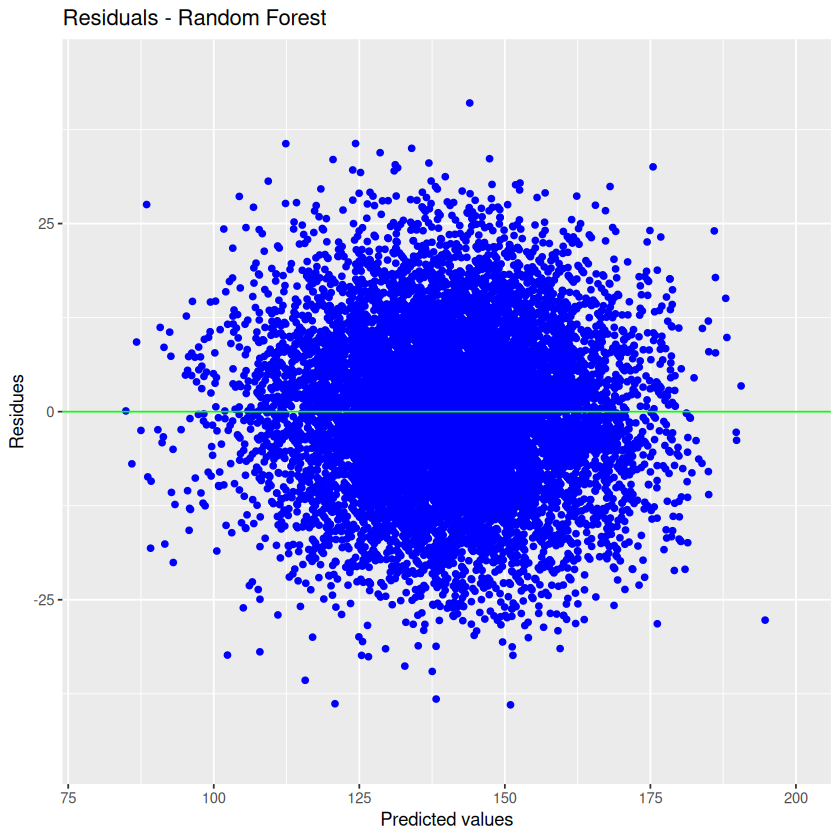

In [ ]:
fit_rf_chol <- rf_chol_Opt$predicted
res.rfr <- YC_train - fit_rf_chol
gplot.res(fit_rf_chol, res.rfr, 80, 200, -45, 45, titre = "Residuals - Random Forest")

The cloud is homogeneous, thick in the middle, and thins out symmetrically. It is pure white noise. This proves that the Random Forest has captured almost all the logical structure of the data, leaving only randomness behind.

In [ ]:
y_pred_Opt <- predict(rf_chol_Opt, XC_test)

sse <- sum((YC_test - y_pred_Opt)^2)
sst <- sum((YC_test - mean(y_pred_Opt))^2)
r2_test <- 1 - (sse / sst)
cat(sprintf("R² coefficient on the test set : %.4f\n", r2_test))

print("Importance of variables :")
print(importance(rf_chol_Opt))

R² coefficient on the test set : 0.6808
[1] "Importance of variables :"
                                      %IncMSE IncNodePurity
Age                               9.972469817     217643.92
Height_cm                        12.060205053     128138.35
R_Weight_kg                      19.343422489     126279.60
R_BMI                            16.581267144     128700.78
Systolic_BP                      14.213727506     115378.43
Diastolic_BP                     13.927279271     101098.33
Cholesterol_Total               334.795308547    2560756.85
Cholesterol_HDL                   6.069654541     101131.30
Fasting_Blood_Sugar               1.023598649     121403.83
Sleep_Hours                      -1.560207465      52598.78
Stress_Level_-0.514607744060628  -2.049948092      12221.03
Stress_Level_-0.862688062460241  -0.359449212      10779.54
Stress_Level_-1.21076838085985   -1.748272141      11277.22
Stress_Level_-1.55884869925947   -1.980589137      11598.37
Stress_Level_0.1815528927385

In [ ]:
cat("Number of input variables :", ncol(XC_train), "\n")
oob_err <- 1 - tail(rf_chol_Opt$rsq, 1)
cat(sprintf("Optimal OOB error : %.4f\n", oob_err))
cat(sprintf("Optimal OOB error of the test sample : %.4f\n", 1 - r2_test))

Number of input variables : 19 
Optimal OOB error : 0.3332
Optimal OOB error of the test sample : 0.3192


With the optimal model, we finally obtain an OOB error on the test sample of 0.32, still equivalent with Python.

#### v) Model Aggregation : Boosting

In this section we will create a prediction model using boosting.

In [ ]:
XC_boost_train <- df_train[, !(names(df_train) %in% c("Patient_ID", "Heart_Disease_Risk"))]
YC_boost_train <- df_train$Cholesterol_LDL

XC_boost_test <- df_test[, !(names(df_test) %in% c("Patient_ID", "Heart_Disease_Risk"))]
YC_boost_test <- df_test$Cholesterol_LDL

quanti <- c("Age", "Height_cm", "R_Weight_kg", "R_BMI", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", "Cholesterol_HDL", "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

XC_boost_train_scaled <- scale(XC_boost_train[, quanti])
XC_boost_test[, quanti] <- scale(XC_boost_test[, quanti], 
                          center = attr(XC_boost_train_scaled, "scaled:center"), 
                          scale  = attr(XC_boost_train_scaled, "scaled:scale"))
XC_boost_train[, quanti] <- XC_train_scaled

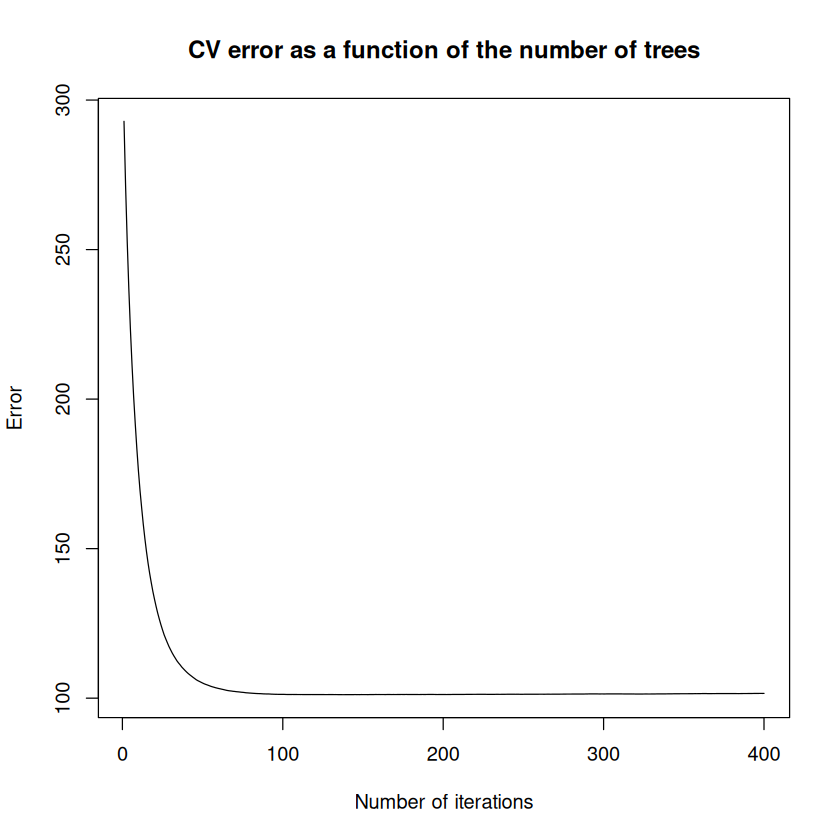

In [ ]:
boost.reg = gbm(Cholesterol_LDL ~ ., data = XC_boost_train, distribution = "gaussian", n.trees = 400, 
    cv.folds = 5, n.minobsinnode = 5, shrinkage = 0.1, verbose = FALSE)

plot(boost.reg$cv.error, type = "l", 
     main = "CV error as a function of the number of trees",
     xlab = "Number of iterations", ylab = "Error")

R needs 100 iterations to arrive at an error of 100, against 30 for Python.

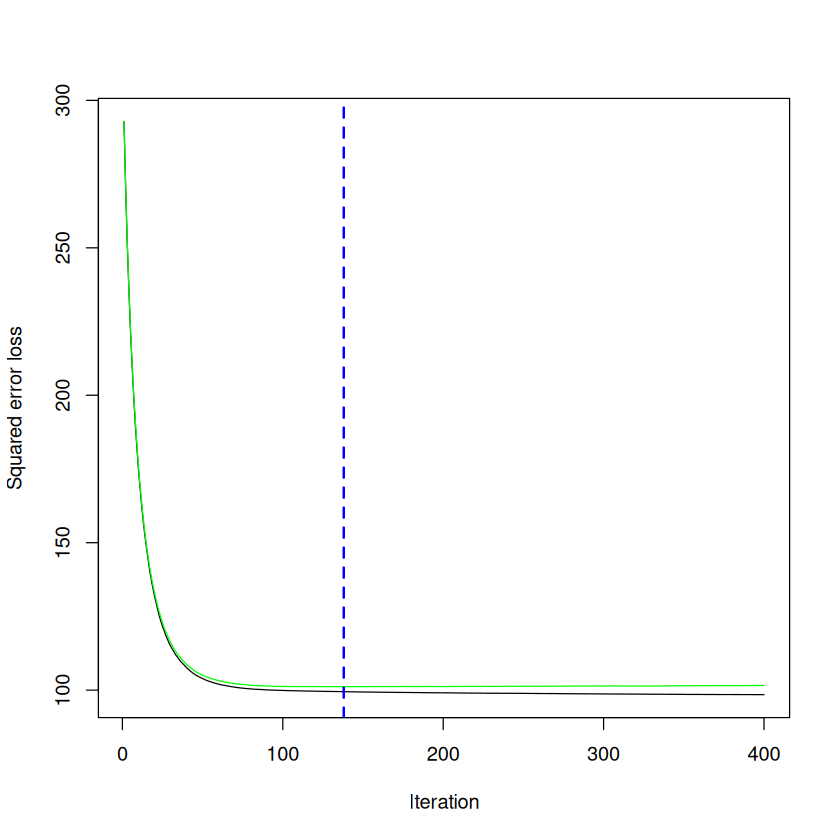

In [ ]:
best.iter=gbm.perf(boost.reg,method="cv")

As in classification, we will choose the best combination of parameters. The preceding cells only help us to get an idea of ​​the orders of the scale.

In [ ]:
shrink_vals <- c(0.001, 0.01, 0.05, 0.1)
results <- data.frame()

for (s in shrink_vals) {
  m <- gbm(Cholesterol_LDL ~ ., data = XC_boost_train, distribution = "gaussian",
           n.trees = 150, shrinkage = s, cv.folds = 10)
  
  best_t <- gbm.perf(m, method = "cv", plot.it = FALSE)
  results <- rbind(results, data.frame(shrinkage = s, n.trees = best_t, error = m$cv.error[best_t]))
}

best_combi=results[order(results$error), ][1, ]

In [ ]:
print(best_combi)

  shrinkage n.trees    error
4       0.1     127 101.0975


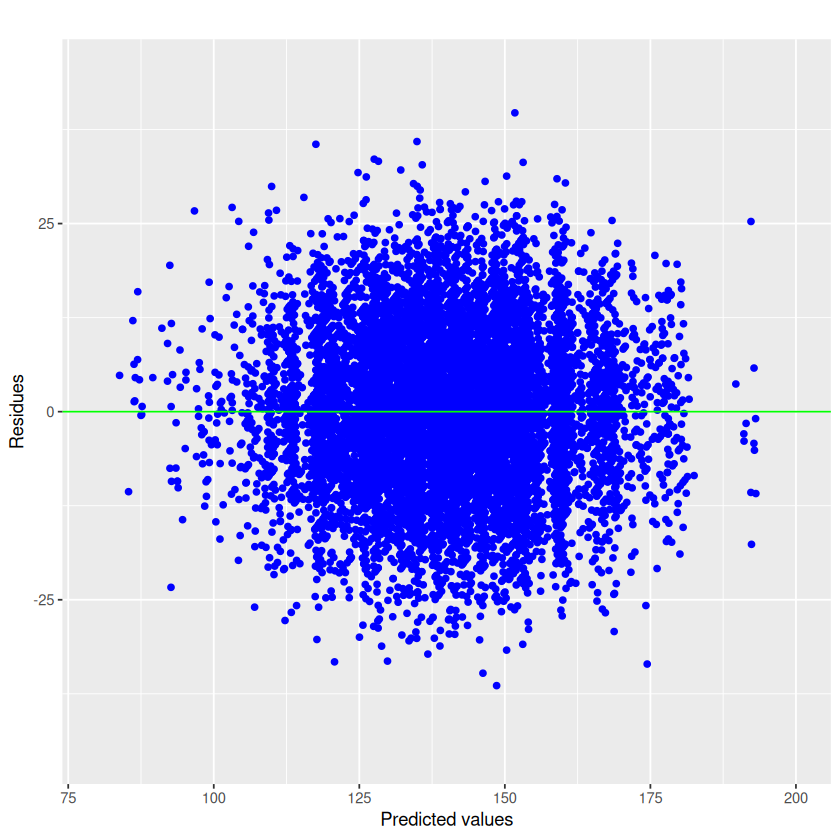

In [ ]:
fit.boostr=boost.reg$fit
res.boostr=fit.boostr-XC_boost_train[,"Cholesterol_LDL"]
gplot.res(fit.boostr,res.boostr, 80, 200, -45, 45, titre="")

The cloud shape is good. The model works well.

In [ ]:
pred_boost <- predict(boost.reg, newdata = XC_boost_test, n.trees = 283, shrinkage=0.05, type = "response")
err=sum((pred_boost-XC_boost_test[,"Cholesterol_LDL"])^2)/nrow(XC_boost_test)
var_test = var(XC_boost_test[,"Cholesterol_LDL"])

print(paste("The squared error on the test sample of this model is", err, "."))
print(paste("Total variance :", var_test))
print(paste("Error margin :", err / var_test))

[1] "The squared error on the test sample of this model is 100.642805022212 ."
[1] "Total variance : 328.493929532066"
[1] "Error margin : 0.306376453183094"


Finally, we obtain an error of 0.31, egal at the one obtained in Python.

#### vi) Neural network

In [ ]:
df_train_reg <- as.data.frame(XC_train)
df_train_reg$Cholesterol_LDL <- YC_train

df_test_reg <- as.data.frame(XC_test)
df_test_reg$Cholesterol_LDL <- YC_test

In [ ]:
stopImplicitCluster()
set.seed(42)

In [ ]:
control_cv_reg <- trainControl(method = "cv", number = 8, allowParallel = FALSE)
grid_hiperpar_reg <- expand.grid(size = c(3, 4, 5), decay = c(0.001, 0.01, 0.05, 0.1))

tuned_nn_regressor <- train(
  Cholesterol_LDL ~ .,
  data = df_train_reg,
  method = "nnet",
  trControl = control_cv_reg,
  tuneGrid = grid_hiperpar_reg,
  preProcess = "range",
  linout = TRUE, 
  trace = FALSE,
  maxit = 600 
)

print(tuned_nn_regressor)

Neural Network 

12000 samples
   19 predictor

Pre-processing: re-scaling to [0, 1] (19) 
Resampling: Cross-Validated (8 fold) 
Summary of sample sizes: 10501, 10499, 10500, 10501, 10499, 10500, ... 
Resampling results across tuning parameters:

  size  decay  RMSE      Rsquared   MAE      
  3     0.001  12.06940  0.6788613   9.599881
  3     0.010  14.98181  0.5217330  11.933444
  3     0.050  10.04852  0.6835498   7.996034
  3     0.100  10.06759  0.6823718   7.997294
  4     0.001  12.94519  0.5741459  10.298218
  4     0.010  13.90997  0.5506291  11.058938
  4     0.050  11.01541  0.6836697   8.764045
  4     0.100  10.07501  0.6819335   8.018751
  5     0.001  15.00761  0.5019801  11.954854
  5     0.010  10.09026  0.6810611   8.033838
  5     0.050  10.07938  0.6817194   8.026379
  5     0.100  10.08892  0.6810887   8.033857

RMSE was used to select the optimal model using the smallest value.
The final values used for the model were size = 3 and decay = 0.05.


   size decay     RMSE  Rsquared       MAE    RMSESD RsquaredSD     MAESD
1     3 0.001 12.06940 0.6788613  9.599881 3.6620122 0.01821598 2.9142633
2     3 0.010 14.98181 0.5217330 11.933444 3.9796716 0.30616864 3.1738283
3     3 0.050 10.04852 0.6835498  7.996034 0.2675289 0.01848095 0.2461694
4     3 0.100 10.06759 0.6823718  7.997294 0.2590996 0.01737919 0.2353455
5     4 0.001 12.94519 0.5741459 10.298218 4.1118114 0.27896917 3.2707850
6     4 0.010 13.90997 0.5506291 11.058938 4.1830152 0.30766520 3.3528662
7     4 0.050 11.01541 0.6836697  8.764045 2.7181919 0.01889822 2.1699857
8     4 0.100 10.07501 0.6819335  8.018751 0.2743235 0.01845586 0.2533525
9     5 0.001 15.00761 0.5019801 11.954854 3.9001477 0.33483586 3.1045910
10    5 0.010 10.09026 0.6810611  8.033838 0.2514388 0.01766210 0.2258062
11    5 0.050 10.07938 0.6817194  8.026379 0.2614269 0.01705904 0.2337111
12    5 0.100 10.08892 0.6810887  8.033857 0.2412060 0.01688347 0.2045095
[1] "####################"
[1] "Optima

  size decay
3    3  0.05


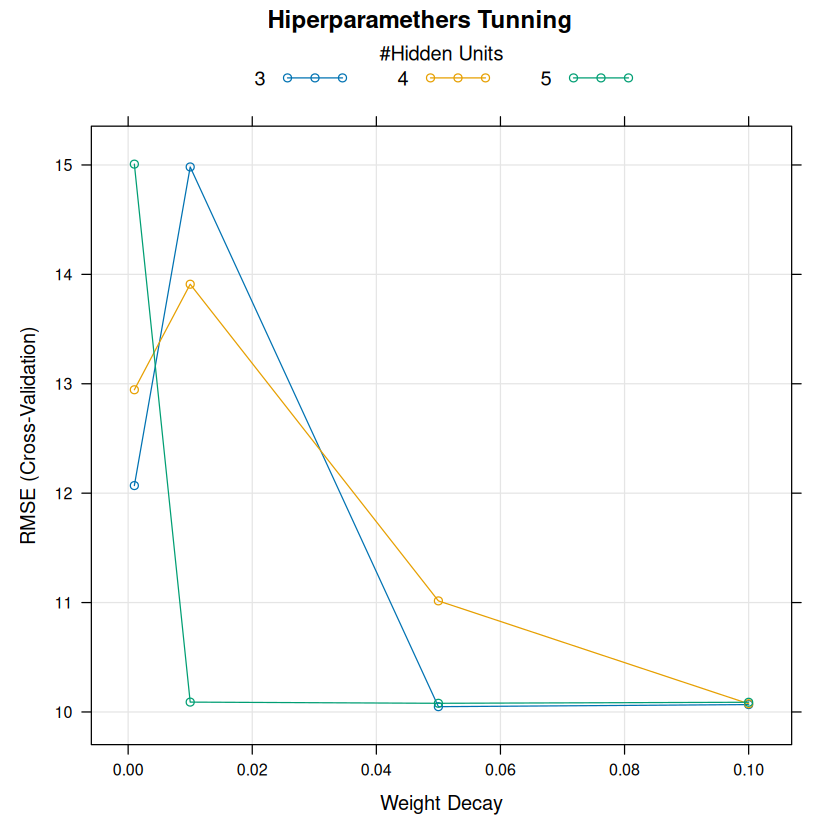

In [ ]:
# Optimization metrics
print(tuned_nn_regressor$results)
print("####################")
print("Optimal parameters")
print("####################")
print(tuned_nn_regressor$bestTune)
plot(tuned_nn_regressor, main = "Hiperparamethers Tunning")

The results show that hyperparameters have a significant influence on the performance of the neural network. In particular, more complex architectures (size = 5) do not improve predictions and, in some cases, even degrade the metrics, suggesting the occurrence of overfitting. On the other hand, higher regularization (decay = 0.1) yields more stable models with lower prediction error, as it limits excessively large weights and improves generalization ability. Consequently, the best configuration corresponds to a relatively simple and properly regularized neural network, capable of capturing the main relationships of the problem without introducing unnecessary complexity.

In [ ]:
# Final predictions
preds_reg_ldl <- predict(tuned_nn_regressor, newdata = df_test_reg)
valores_reales_ldl <- df_test_reg$Cholesterol_LDL

In [ ]:
# Evaluate test sample
postResample(pred = preds_reg_ldl, obs = valores_reales_ldl)

RMSE   Rsquared        MAE 
10.0020649  0.6960371  7.9897387

The optimized neural network performs well in predicting LDL cholesterol, striking an appropriate balance between accuracy and generalization ability. The model accounts for nearly 70% of the variability in the target variable with relatively low mean errors, confirming that the available clinical and lifestyle variables contain a significant amount of predictive information regarding LDL cholesterol levels.

Furthermore, the results show that a simple, properly regularized neural network may be sufficient to model this type of tabular medical data without the need for overly complex architectures.

Again, the neural network obtain the same results than Python. 

### c. Model Comparison

We will do a recap of the metrics for each method that we used and plot the predicted values VS the values that we were supposed to have.

Using 138 trees...




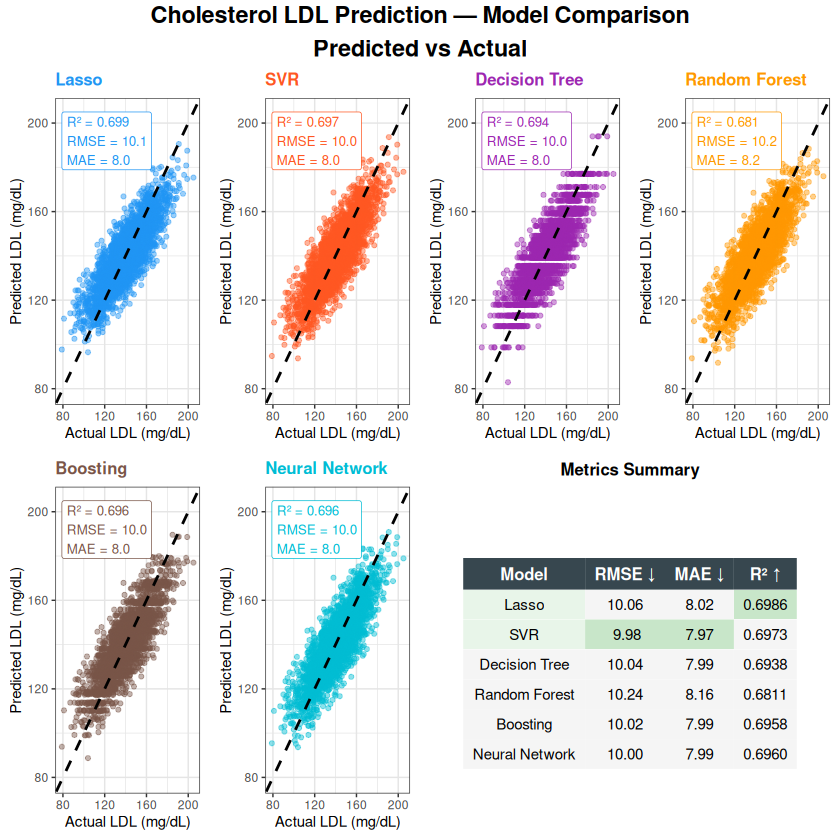

In [ ]:
# ── Prédictions (adapter selon vos objets R) ───────────────────────────────
predictions <- list(
  "Lasso"          = list(y_pred = as.vector(predict(lasso_cv, as.matrix(XC_test))), y_true = YC_test),
  "SVR"            = list(y_pred = predict(best_svr_model,       XC_test), y_true = YC_test),
  "Decision Tree"  = list(y_pred = predict(optimal_tree_reg,     XC_test), y_true = YC_test),
  "Random Forest"  = list(y_pred = predict(rf_chol_Opt,          XC_test), y_true = YC_test),
  "Boosting"       = list(y_pred = predict(boost.reg,            XC_boost_test), y_true = YC_boost_test),
  "Neural Network" = list(y_pred = predict(tuned_nn_regressor,   df_test_reg), y_true = YC_test)
)

colors <- c(
  "Lasso"          = "#2196F3",
  "SVR"            = "#FF5722",
  "Decision Tree"  = "#9C27B0",
  "Random Forest"  = "#FF9800",
  "Boosting"       = "#795548",
  "Neural Network" = "#00BCD4"
)

# ── Calcul des métriques ───────────────────────────────────────────────────
compute_metrics <- function(y_pred, y_true) {
  list(
    RMSE = rmse(y_true, y_pred),
    MAE  = mae(y_true, y_pred),
    R2   = cor(y_true, y_pred)^2
  )
}

metrics <- lapply(predictions, function(p) compute_metrics(p$y_pred, p$y_true))
model_names <- names(predictions)

# ── Scatter plots ──────────────────────────────────────────────────────────
make_scatter <- function(name) {
  p     <- predictions[[name]]
  m     <- metrics[[name]]
  color <- colors[name]
  df    <- data.frame(actual = p$y_true, predicted = p$y_pred)
  lims  <- range(c(df$actual, df$predicted))

  label <- sprintf("R² = %.3f\nRMSE = %.1f\nMAE = %.1f", m$R2, m$RMSE, m$MAE)

  ggplot(df, aes(x = actual, y = predicted)) +
    geom_point(alpha = 0.45, size = 1.2, color = color) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", linewidth = 0.8) +
    coord_cartesian(xlim = lims, ylim = lims) +
    annotate("label", x = lims[1], y = lims[2],
             label = label, hjust = 0, vjust = 1,
             size = 2.8, color = color,
             fill = "white", label.r = unit(0.15, "lines"),
             label.padding = unit(0.3, "lines")) +
    labs(
      title = name,
      x     = "Actual LDL (mg/dL)",
      y     = "Predicted LDL (mg/dL)"
    ) +
    theme_bw(base_size = 9) +
    theme(
      plot.title   = element_text(face = "bold", color = color, size = 10),
      panel.grid   = element_line(color = "grey90"),
      plot.margin  = ggplot2::margin(6, 6, 6, 6)
    )
}

scatter_plots <- lapply(model_names, make_scatter)

# ── Tableau récapitulatif ──────────────────────────────────────────────────
metrics_df <- data.frame(
  Model = model_names,
  RMSE  = sapply(metrics, function(m) round(m$RMSE, 2)),
  MAE   = sapply(metrics, function(m) round(m$MAE,  2)),
  R2    = sapply(metrics, function(m) round(m$R2,   4)),
  stringsAsFactors = FALSE
)

best_r2   <- which.max(metrics_df$R2)
best_rmse <- which.min(metrics_df$RMSE)
best_mae  <- which.min(metrics_df$MAE)

# Couleurs cellules : vert pour le meilleur, gris clair sinon
n <- nrow(metrics_df)
fill_model <- rep("#f5f5f5", n)
fill_rmse  <- rep("#f5f5f5", n);  fill_rmse[best_rmse]  <- "#C8E6C9"
fill_mae   <- rep("#f5f5f5", n);  fill_mae[best_mae]    <- "#C8E6C9"
fill_r2    <- rep("#f5f5f5", n);  fill_r2[best_r2]      <- "#C8E6C9"

# Ligne verte entière si meilleur sur au moins 1 critère
best_rows <- unique(c(best_r2, best_rmse, best_mae))
fill_model[best_rows] <- "#E8F5E9"

table_grob <- tableGrob(
  metrics_df,
  rows = NULL,
  cols = c("Model", "RMSE ↓", "MAE ↓", "R² ↑"),
  theme = ttheme_minimal(
    colhead = list(
      bg_params  = list(fill = "#37474F"),
      fg_params  = list(col = "white", fontface = "bold", fontsize = 10)
    ),
    core = list(
      bg_params  = list(fill = cbind(fill_model, fill_rmse, fill_mae, fill_r2)),
      fg_params  = list(fontsize = 9)
    )
  )
)

title_grob <- textGrob(
  "Metrics Summary",
  gp = gpar(fontsize = 10, fontface = "bold")
)

table_with_title <- arrangeGrob(title_grob, table_grob, ncol = 1, heights = c(0.1, 1))

# ── Assemblage final (3×3 : 7 scatters + 1 tableau 2 colonnes) ────────────
# Ligne 0 : scatter 1,2,3
# Ligne 1 : scatter 4,5,6
# Ligne 2 : scatter 7 + tableau (2 cols)

lay <- rbind(
  c(1, 2, 3, 4),
  c(5, 6, 7, 7)
)

plots_all <- c(scatter_plots, list(table_with_title))

grid.arrange(
  grobs  = plots_all,
  layout_matrix = lay,
  top    = textGrob(
    "Cholesterol LDL Prediction — Model Comparison\nPredicted vs Actual",
    gp = gpar(fontsize = 14, fontface = "bold")
  ),
  widths  = c(1, 1, 1, 1),
  heights = c(1, 1)
)

As seen during all the R analysis, the results of R are equivalent (if not egal) to the one of the Python. The Lasso is still the best in $R²$ criteria, with a better score. However it is not that efficient with RMSE and MAE score. The SVR appears like the best model in R (according to RMSE and MAE), however those scores are better in the Lasso of Python.

Overall models, Lasso in Python seems to be the best compromise. Moreover, it is more simple and quick to run because it deletes a lot of variables. 

## General Conclusion

The results obtained in Python and the ones obtained in R are equivalent. The difference between the 2 is more on how intuitive and fast it is to obtain those results.

We thought that using R would be more appropriated, according to the fact that it is a language used especially for statistics and data analysis. However the packages used were easier to apply in Python, the execution time was also quicker, and the printing (graphs, plots...) were cuter :) . We can also note that R is not an appropriate language to create Neural Network and we had many troubles with that. 

This choice is biaised by the fact that we are more familiarize with python language than R's, maybe knowing more about R would have simplify our work in this language. 